In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST, CIFAR10

import time
from sklearn.manifold import TSNE
import math
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
def plot_training_results(train_losses, val_losses, eval_interval, title):
    plt.figure(figsize=(6, 4))

    # Map to real global steps
    steps = (np.arange(len(train_losses)) + 1) * eval_interval

    plt.plot(steps, train_losses, label='Train Loss', alpha=0.5)
    plt.plot(steps, val_losses, label='Val Loss')

    plt.title(title)
    plt.xlabel('Global Steps')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def lr_lambda(step):
    if step < warmup_steps:
        # Linear warmup
        return step / warmup_steps
    else:
        # Cosine decay
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * progress))

# **MNIST - Gaussian VAE**

In [ ]:
# gaussian VAE implementation
class encoder(nn.Module):
  def __init__(self, inp_size, latent_dim):
    super().__init__()
    self.hidden_layer = nn.Linear(inp_size, 256, bias=True)
    self.relu = nn.ReLU()
    self.mean_ = nn.Linear(256,latent_dim, bias=True)
    self.log_var = nn.Linear(256,latent_dim, bias=True)

  def forward(self, x):
    N, _ = x.shape
    h = self.relu(self.hidden_layer(x))
    mu = self.mean_(h)
    log_var = self.log_var(h)
    var = torch.exp(log_var)
    eps = torch.randn(N, mu.shape[-1]).to(x.device) # sampling random values from standard normal distribution
    latent_z = mu + torch.sqrt(var) * eps # reparameterization
    return latent_z, mu, var

# global fn for soft clamping for smoother gradient flows
def soft_clamp(x, min_val, max_val):
    return min_val + (max_val - min_val) * torch.sigmoid(x)

class decoder(nn.Module):
  def __init__(self, output_size, latent_dim):
    super().__init__()
    self.hidden_layer = nn.Linear(latent_dim, 256, bias=True)
    self.relu = nn.ReLU()
    self.mean_ = nn.Linear(256, output_size, bias=True)
    # self.log_var = nn.Linear(256, output_size, bias=True) # per-pixel learnable variance weights conditioned on latent code z
    self.log_scale = nn.Parameter(torch.Tensor([0.0])) # global learnable variance not conditioned on latent code z
    # self.log_scale = nn.Parameter(torch.zeros(output_size))

  def forward(self, latent_z):
    h = self.relu(self.hidden_layer(latent_z))
    mu = self.mean_(h)
    # log_var = self.log_var(h)
    # log_var = torch.clamp(log_var, min=-4, max=4) # hard clamp so that variance doesn't become very large or small
    # log_var = soft_clamp(log_var, min_val=-10, max_val=10) # soft clamp, for allowing smoother differentiation at min and max boundaries
    # var = torch.exp(log_var)
    var = torch.exp(self.log_scale)
    return mu, var

class VAE(nn.Module):
  def __init__(self, inp_size, output_size, latent_dim):
    super().__init__()
    self.encoder = encoder(inp_size, latent_dim)
    self.decoder = decoder(output_size, latent_dim)

  def forward(self, x):
    latent_z, mu_encoder, var_encoder = self.encoder(x)
    mu_decoder, var_decoder = self.decoder(latent_z)

    return mu_encoder, var_encoder, mu_decoder, var_decoder



In [ ]:
def calc_batch_loss(model, x, device):
  x = x.to(device)
  mu_encoder, var_encoder, mu_decoder, var_decoder = model(x)
  dkl = torch.sum(1+torch.log(var_encoder)-torch.square(mu_encoder)-var_encoder, dim=-1).mean() * (-1/2)
  dist = torch.distributions.Normal(mu_decoder, torch.sqrt(var_decoder))
  reconst_loss = -1 * dist.log_prob(x).sum(dim=-1).mean() # gaussian log likelihood
  # reconst_loss = 0.5 * (
  #       torch.log(var_decoder) +
  #       (x - mu_decoder) ** 2 / var_decoder
  #   )
  # reconst_loss = reconst_loss.sum(dim=1).mean()
  loss = reconst_loss + dkl
  return loss, reconst_loss, dkl, mu_decoder.mean(), var_decoder.mean()

In [ ]:
def evaluate(loader, model, device, max_batch=5):
  total_loss = 0
  total_reconst_loss = 0
  total_dkl = 0
  total_mu_decoder = 0
  total_var_decoder = 0
  if max_batch <= 0:
    return float("nan")
  elif max_batch is None:
    max_batch = len(loader)
  else:
    max_batch = min(max_batch, len(loader))

  for i, (x, _) in enumerate(loader):
    if i < max_batch:
      with torch.no_grad():
        x = x.flatten(1)
        loss, reconst_loss, dkl, mu_decoder, var_decoder = calc_batch_loss(model, x, device)
      total_loss += loss.item()
      total_reconst_loss += reconst_loss.item()
      total_dkl += dkl.item()
      total_mu_decoder += mu_decoder.item()
      total_var_decoder += var_decoder.item()
    else:
      break

  return total_loss/max_batch, total_reconst_loss/max_batch, total_dkl/max_batch, total_mu_decoder/max_batch, total_var_decoder/max_batch

In [ ]:
def sample_from_decoder(model, x, device):
  x = x.to(device)
  with torch.no_grad():
    mu_encoder, var_encoder, mu_decoder, var_decoder = model(x)
  eps = torch.randn(mu_decoder.shape[0], mu_decoder.shape[-1], device=device)
  sampled_data = mu_decoder + torch.sqrt(var_decoder) * eps
  return sampled_data

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [ ]:
mnist_train = MNIST(
    root="/content/drive/My Drive/PyTorch Exercise",
    train=True,
    download=True,
    transform=transform
    )

mnist_test = MNIST(
    root="/content/drive/My Drive/PyTorch Exercise",
    train=False,
    download=True,
    transform=transform
    )

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.4MB/s]


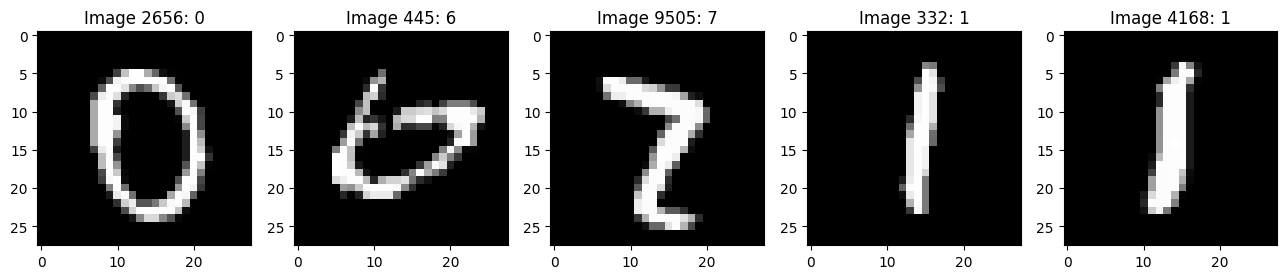

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(123)

random_indices = np.random.choice(len(mnist_test), size=5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(16, 8))

for ax,i in zip(axes, random_indices):
  ax.imshow(mnist_test[i][0].squeeze(), cmap="gray")
  ax.set_title(f"Image {i}: {mnist_test[i][1]}")

plt.show()

In [ ]:
samples = torch.stack([mnist_test[i][0] for i in random_indices], dim=0)
labels = torch.stack([torch.tensor(mnist_test[i][1]) for i in random_indices], dim=0)

In [ ]:
train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True, num_workers=0)
test_loader = DataLoader(mnist_test, batch_size=64, shuffle=False, num_workers=0)

In [ ]:
torch.manual_seed(123)
model1 = VAE(28*28, 28*28, 32)
model1.to(device)

optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.0001)
epochs = 50

# total_steps = epochs * len(train_loader)
# warmup_steps = int(0.05 * total_steps)  # 5% warmup
# scheduler1 = torch.optim.lr_scheduler.LambdaLR(optimizer1, lr_lambda)

global_step1 = 0
train_losses1, val_losses1 = [], []
train_reconst_losses1, val_reconst_losses1 = [], []
train_dkl_losses1, val_dkl_losses1 = [], []
train_var_decoder_lst1, val_var_decoder_lst1 = [], []
var_grad_norm_lst1 = []
lr_lst1 = []

t1 = time.time()

model1.train()
for epoch in range(epochs):
  for x, _ in train_loader:
    optimizer1.zero_grad()
    x = x.flatten(1)
    loss, _, _, _, _ = calc_batch_loss(model1, x, device)
    loss.backward()
    var_grad_norm1 = model1.decoder.log_scale.grad.data.norm()
    # var_grad_norm1 = model1.decoder.log_var.weight.grad.data.norm()
    var_grad_norm_lst1.append(var_grad_norm1)
    # lr_lst1.append(scheduler1.get_last_lr()[0])
    optimizer1.step()
    # scheduler1.step()
    global_step1 += 1

    if global_step1 % 500 == 0:
      model1.eval()
      train_loss1, train_reconst_loss1, train_dkl1, train_mu_decoder1, train_var_decoder1 = evaluate(train_loader, model1, device, max_batch=20)
      val_loss1, val_reconst_loss1, val_dkl1, val_mu_decoder1, val_var_decoder1 = evaluate(test_loader, model1, device, max_batch=20)
      model1.train()
      print(f"Epoch: {epoch:3d} \t\t Step: {global_step1:5d}")
      print(f"\t\t\tTrain Loss: {train_loss1}")
      print(f"\t\t\tValidation Loss: {val_loss1}")
      train_losses1.append(train_loss1)
      val_losses1.append(val_loss1)
      train_reconst_losses1.append(train_reconst_loss1)
      val_reconst_losses1.append(val_reconst_loss1)
      train_dkl_losses1.append(train_dkl1)
      val_dkl_losses1.append(val_dkl1)
      train_var_decoder_lst1.append(train_var_decoder1)
      val_var_decoder_lst1.append(val_var_decoder1)
      if global_step1 % 1000 == 0:
        model1.eval()
        flatten_samples = samples.flatten(1)
        reconstructed = sample_from_decoder(model1, flatten_samples, device).reshape(5, 1, 28, 28).cpu().numpy()
        fig, axes = plt.subplots(1, 5, figsize=(16, 8))
        for ax,i in zip(axes, range(5)):
          ax.imshow(reconstructed[i].squeeze(), cmap="gray")
          ax.set_title(f"Image {i}: {labels[i]}")
        plt.show()
        model1.train()

t2 = time.time()

print(f"Total training time: {t2-t1}s")

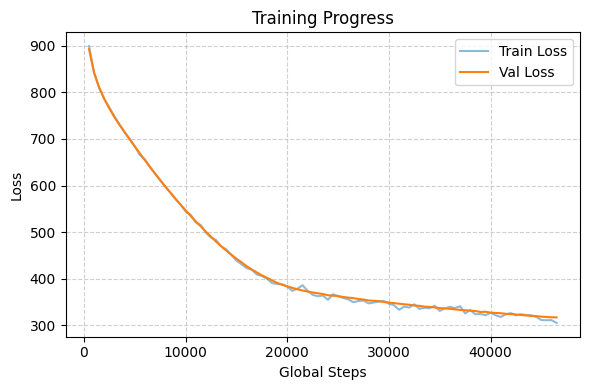

In [ ]:
plot_training_results(train_losses1, val_losses1, 500, title="Training Progress")

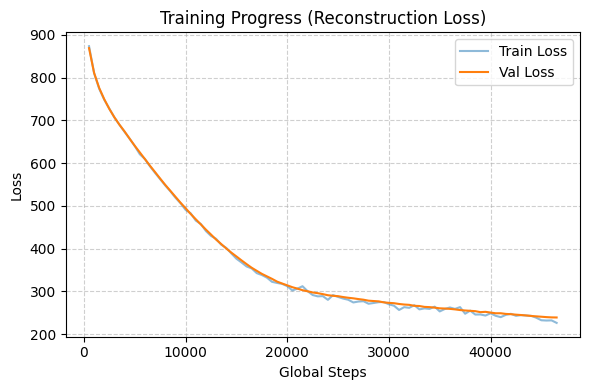

In [ ]:
plot_training_results(train_reconst_losses1, val_reconst_losses1, 500, title="Training Progress (Reconstruction Loss)")

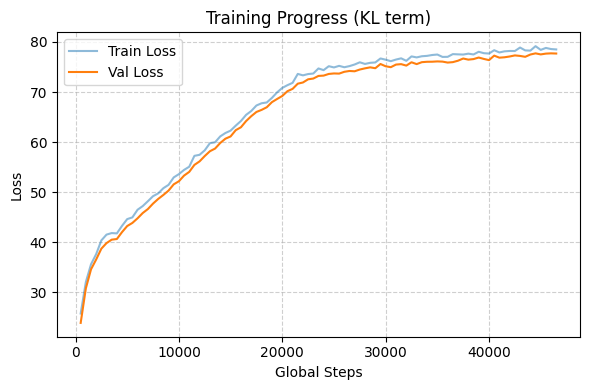

In [ ]:
plot_training_results(train_dkl_losses1, val_dkl_losses1, 500, title="Training Progress (KL term)")

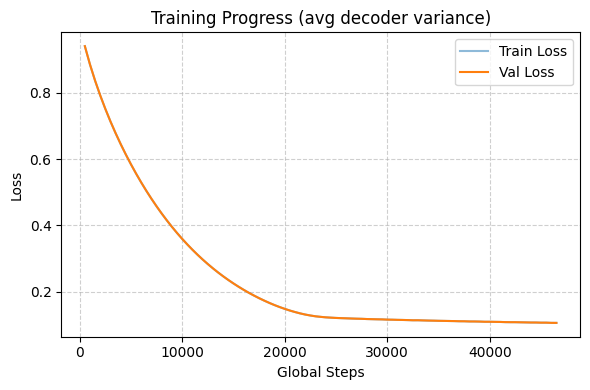

In [ ]:
plot_training_results(train_var_decoder_lst1, val_var_decoder_lst1, 500, title="Training Progress (avg decoder variance)")

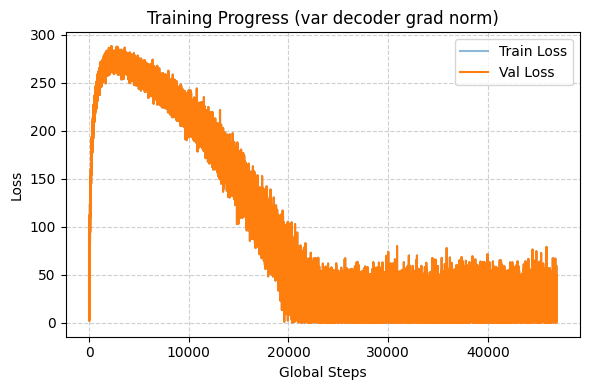

In [ ]:
plot_training_results([var.cpu().numpy() for var in var_grad_norm_lst1], [var.cpu().numpy() for var in var_grad_norm_lst1], 1, title="Training Progress (var decoder grad norm)")


Extracting 32D latents...

Applying t-SNE (this may take a minute)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 10000 samples in 0.936s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 1.820162
[t-SNE] KL divergence after 250 iterations with early exaggeration: 85.667313
[t-SNE] KL divergence after 1000 iterations: 1.769248


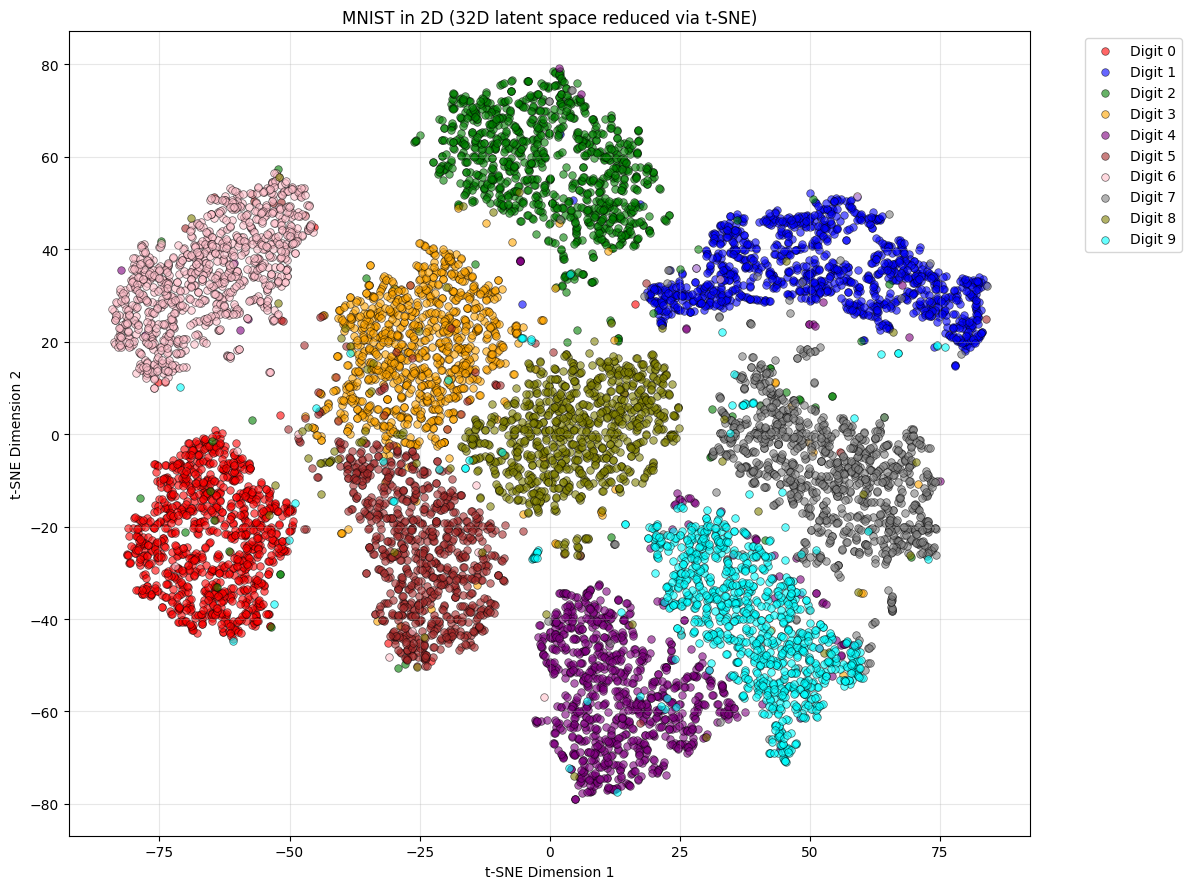


t-SNE visualization complete!
Original latent shape: (10000, 32)
t-SNE reduced shape: (10000, 2)


In [ ]:
# visualizing sampled latent vectors from approximate posterior (probabilistic encoder)

print("\nExtracting 32D latents...")
all_latents = []
all_labels = []

model1.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        img_flatten = images.flatten(1)
        latents_z, _, _ = model1.encoder(img_flatten)

        all_latents.append(latents_z.cpu().numpy())
        all_labels.append(labels.numpy())

latents_32d = np.vstack(all_latents)
labels = np.concatenate(all_labels)

# Apply t-SNE to reduce 32D to 2D
print("\nApplying t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=1)
latents_2d = tsne.fit_transform(latents_32d)

# Plot
plt.figure(figsize=(12, 9))

# Define colors for each digit (0-9)
colors = ['red', 'blue', 'green', 'orange', 'purple',
          'brown', 'pink', 'gray', 'olive', 'cyan']

# Plot each digit with its own color
for digit in range(10):
    mask = labels == digit
    plt.scatter(latents_2d[mask, 0], latents_2d[mask, 1],
                c=colors[digit], label=f'Digit {digit}',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('MNIST in 2D (32D latent space reduced via t-SNE)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nt-SNE visualization complete!")
print(f"Original latent shape: {latents_32d.shape}")
print(f"t-SNE reduced shape: {latents_2d.shape}")

In [ ]:
for i in range(latents_32d.shape[-1]):
  print(f"Dimension-{i}\t\tMean:{latents_32d[:,i].mean():.3f}\t\tVariance:{latents_32d[:,i].std()**2:.3f}")

Dimension-0		Mean:0.240		Variance:1.246
Dimension-1		Mean:-0.342		Variance:1.421
Dimension-2		Mean:0.125		Variance:1.065
Dimension-3		Mean:0.160		Variance:1.277
Dimension-4		Mean:0.342		Variance:1.123
Dimension-5		Mean:0.160		Variance:1.172
Dimension-6		Mean:-0.012		Variance:1.385
Dimension-7		Mean:-0.166		Variance:1.500
Dimension-8		Mean:-0.346		Variance:1.264
Dimension-9		Mean:0.075		Variance:1.209
Dimension-10		Mean:0.243		Variance:1.052
Dimension-11		Mean:0.020		Variance:1.246
Dimension-12		Mean:0.141		Variance:1.203
Dimension-13		Mean:-0.192		Variance:1.404
Dimension-14		Mean:0.136		Variance:1.472
Dimension-15		Mean:0.007		Variance:1.418
Dimension-16		Mean:-0.304		Variance:1.500
Dimension-17		Mean:0.088		Variance:1.255
Dimension-18		Mean:0.300		Variance:1.298
Dimension-19		Mean:0.078		Variance:1.223
Dimension-20		Mean:-0.002		Variance:1.194
Dimension-21		Mean:0.237		Variance:1.206
Dimension-22		Mean:-0.216		Variance:1.482
Dimension-23		Mean:-0.231		Variance:1.627
Dimension-24		Mea

The latent vectors are spread normally across each dimension

In [ ]:
# interpolating the latents of same digit images and decoding

# first mapping and categorising the latent vector to respective digits
def group_latents_by_label(all_latents, all_labels):
    # Concatenate batches
    latents = np.concatenate(all_latents, axis=0)
    labels = np.concatenate(all_labels, axis=0)

    # Create dict: digit -> list of latents
    latent_dict = {i: [] for i in range(10)}

    for z, y in zip(latents, labels):
        latent_dict[int(y)].append(z)

    # Convert lists to arrays
    for k in latent_dict:
        latent_dict[k] = np.array(latent_dict[k])

    return latent_dict

# interpolation and decoding method
def interpolate_and_decode(model, z1, z2, steps, device):
    """
    z1, z2: tensors of shape (latent_dim,)
    steps: number of interpolation points
    """

    model.eval()

    # Create interpolation coefficients
    alphas = torch.linspace(0, 1, steps, device=device)

    # Store outputs
    samples = []

    with torch.no_grad():
        for alpha in alphas:
            # Linear interpolation in latent space
            z = (1 - alpha) * z1 + alpha * z2
            z = z.unsqueeze(0)  # shape (1, latent_dim)

            # Decode
            mu_decoder, var_decoder = model.decoder(z)

            # Sample from p(x|z)
            eps = torch.randn_like(mu_decoder)
            x_sample = mu_decoder + torch.sqrt(var_decoder) * eps

            samples.append(x_sample.cpu())

    return torch.cat(samples, dim=0)

# fn for sampling, interpolating, decoding and plotting orchestration
def generate_interpolation_grid(
    model,
    latent_dict,
    device,
    steps=4,
    img_shape=(28, 28)
):
    model.eval()

    all_rows = []

    for digit in range(10):
        latents = latent_dict[digit]

        # Randomly pick 2 latent vectors
        idx = np.random.choice(len(latents), size=2, replace=False)
        z1 = torch.tensor(latents[idx[0]], device=device).float()
        z2 = torch.tensor(latents[idx[1]], device=device).float()

        # 🔹 Use your function here
        samples = interpolate_and_decode(model, z1, z2, steps, device)
        samples = samples.cpu().numpy()  # (steps, input_dim)

        # Reshape each sample into image
        row_images = [
            samples[i].reshape(img_shape)
            for i in range(steps)
        ]

        all_rows.append(row_images)

    # 🔹 Plot grid
    fig, axes = plt.subplots(10, steps, figsize=(steps * 2, 20))

    for i in range(10):
        for j in range(steps):
            axes[i, j].imshow(all_rows[i][j], cmap='gray')
            axes[i, j].axis('off')

            if j == 0:
                axes[i, j].set_ylabel(str(i), fontsize=12)

    plt.tight_layout()
    plt.show()

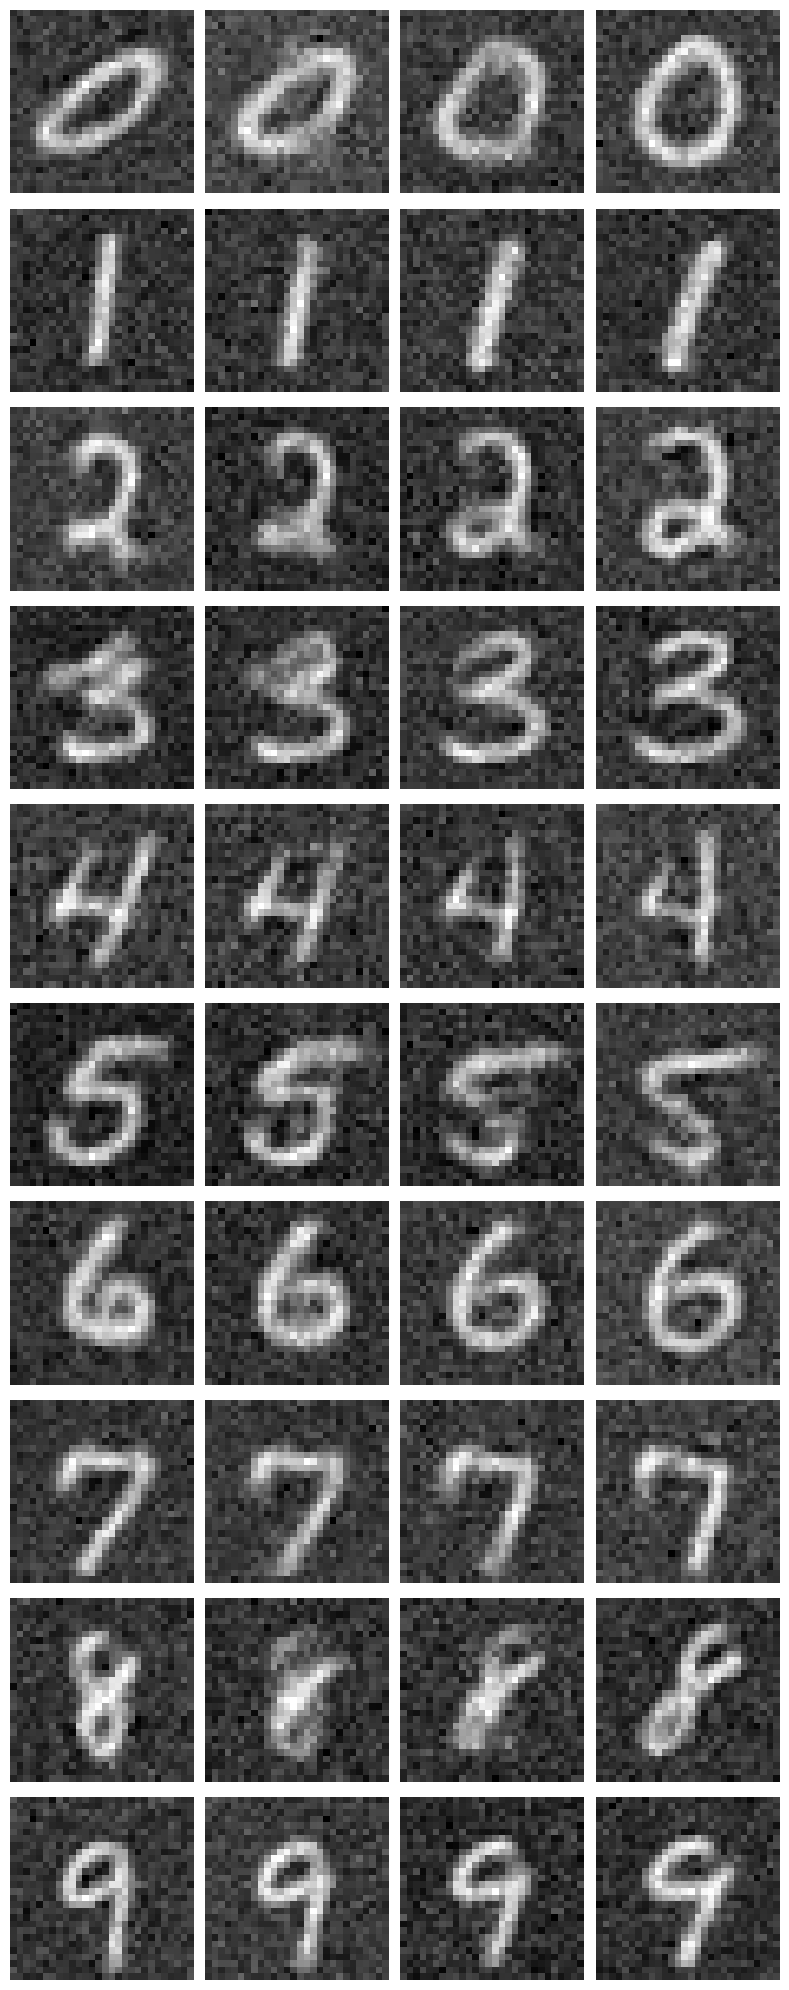

In [ ]:
latent_dict = group_latents_by_label(all_latents, all_labels)

generate_interpolation_grid(model1, latent_dict, device)

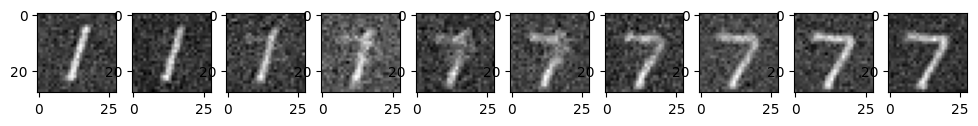

In [ ]:
z1 = torch.tensor(latent_dict[1][0], device=device)
z2 = torch.tensor(latent_dict[7][0], device=device)

interpolated_and_decoded = interpolate_and_decode(model1, z1, z2, steps=10, device=device)

fig, axes = plt.subplots(1, 10, figsize=(12, 20))

for i in range(10):
  axes[i].imshow(interpolated_and_decoded[i].reshape(28, 28).cpu().numpy(), cmap="gray")

plt.show()

Latent: tensor([ 0.4106, -0.1985, -1.5640,  0.4724,  0.1795, -0.0049,  0.5258,  0.0937,
        -0.2023, -0.9426,  0.9353,  1.4652,  1.2515,  1.2069, -0.7943, -1.4196,
        -0.1514, -1.9862,  0.6644, -0.4942, -0.1579, -0.2249, -1.2764,  0.5057,
         0.7100, -0.1826,  0.2842,  0.5091,  0.9886, -0.7245, -0.3431, -1.2621],
       device='cuda:0')


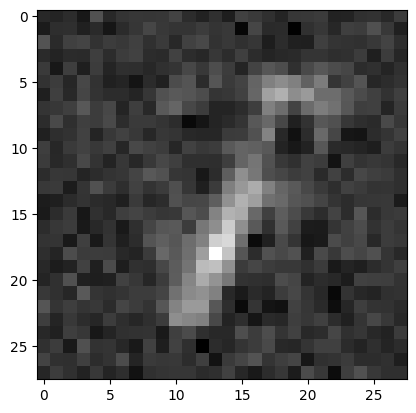

In [ ]:
# randomly sampling latent from prior (standard normal distribution) and decoding
latent_dim = 32
standard_normal_mean = torch.zeros(32, device=device)
standard_normal_std = torch.ones(32, device=device)
eps1 = torch.randn_like(standard_normal_mean, device=device)

sampled_latent_z = standard_normal_mean + standard_normal_std * eps1

print(f"Latent: {sampled_latent_z}")

model1.eval()
with torch.no_grad():
  mu_decoder, var_decoder = model1.decoder(eps1.unsqueeze(0))
  eps2 = torch.randn_like(mu_decoder, device=device)
  reconstructed_sample = mu_decoder + torch.sqrt(var_decoder) * eps2
  reconstructed_sample = reconstructed_sample.reshape(28, 28).cpu().numpy()

plt.imshow(reconstructed_sample, cmap="gray")
plt.show()

# **CIFAR - Gaussian VAE**

In [ ]:
# # gaussian VAE implementation (softplus is difference here)
# class encoder3(nn.Module):
#   def __init__(self, inp_size, latent_dim):
#     super().__init__()
#     self.hidden_layer = nn.Linear(inp_size, 256, bias=True)
#     self.relu = nn.ReLU()
#     self.mean_ = nn.Linear(256,latent_dim, bias=True)
#     self.log_var = nn.Linear(256,latent_dim, bias=True)

#   def forward(self, x):
#     N, _ = x.shape
#     h = self.relu(self.hidden_layer(x))
#     mu = self.mean_(h)
#     log_var = self.log_var(h)
#     var = torch.exp(log_var)
#     eps = torch.randn(N, mu.shape[-1]).to(x.device) # sampling random values from standard normal distribution
#     latent_z = mu + torch.sqrt(var) * eps # reparameterization
#     return latent_z, mu, var

# # global fn for soft clamping for smoother gradient flows
# def soft_clamp(x, min_val, max_val):
#     return min_val + (max_val - min_val) * torch.sigmoid(x)

# class decoder3(nn.Module):
#   def __init__(self, output_size, latent_dim):
#     super().__init__()
#     self.hidden_layer = nn.Linear(latent_dim, 256, bias=True)
#     self.relu = nn.ReLU()
#     self.mean_ = nn.Linear(256, output_size, bias=True)
#     # self.log_var = nn.Linear(256, output_size, bias=True) # per-pixel learnable variance weights conditioned on latent code z
#     self.log_scale = nn.Parameter(torch.Tensor([0.0])) # global learnable variance not conditioned on latent code z
#     # self.log_scale = nn.Parameter(torch.zeros(output_size))

#   def forward(self, latent_z):
#     h = self.relu(self.hidden_layer(latent_z))
#     mu = self.mean_(h)
#     mu = torch.sigmoid(mu)
#     # log_var = self.log_var(h)
#     # log_var = torch.clamp(log_var, min=-4, max=4) # hard clamp so that variance doesn't become very large or small
#     # log_var = soft_clamp(log_var, min_val=-10, max_val=10) # soft clamp, for allowing smoother differentiation at min and max boundaries
#     # var = torch.exp(log_var)
#     var = torch.exp(self.log_scale)
#     var = nn.functional.softplus(var) + 1e-4
#     return mu, var

# class VAE3(nn.Module):
#   def __init__(self, inp_size, output_size, latent_dim):
#     super().__init__()
#     self.encoder = encoder3(inp_size, latent_dim)
#     self.decoder = decoder3(output_size, latent_dim)

#   def forward(self, x):
#     latent_z, mu_encoder, var_encoder = self.encoder(x)
#     mu_decoder, var_decoder = self.decoder(latent_z)

#     return mu_encoder, var_encoder, mu_decoder, var_decoder



In [ ]:
# gaussian VAE implementation
class encoder3(nn.Module):
  def __init__(self, inp_size, latent_dim):
    super().__init__()
    self.hidden_layer = nn.Linear(inp_size, 256, bias=True)
    self.relu = nn.ReLU()
    self.mean_ = nn.Linear(256,latent_dim, bias=True)
    self.log_var = nn.Linear(256,latent_dim, bias=True)

  def forward(self, x):
    N, _ = x.shape
    h = self.relu(self.hidden_layer(x))
    mu = self.mean_(h)
    log_var = self.log_var(h)
    var = torch.exp(log_var)
    return mu, var

def reparameterize(mu, var, n_samples):
    # mu, var: (B, D)
    B, D = mu.shape
    eps = torch.randn(B, n_samples, D, device=mu.device)
    std = torch.sqrt(var).unsqueeze(1)  # (B, 1, D)
    z = mu.unsqueeze(1) + eps * std     # (B, n_samples, D)
    return z

class decoder3(nn.Module):
  def __init__(self, output_size, latent_dim):
    super().__init__()
    self.hidden_layer = nn.Linear(latent_dim, 256, bias=True)
    self.relu = nn.ReLU()
    self.mean_ = nn.Linear(256, output_size, bias=True)
    self.log_scale = nn.Parameter(torch.Tensor([0.0])) # global learnable variance not conditioned on latent code z

  def forward(self, latent_z):
    # latent_z: (B, n_samples, D)
    B, n_samples, D = latent_z.shape
    z = latent_z.reshape(B * n_samples, D)
    h = self.relu(self.hidden_layer(z))
    mu = self.mean_(h)  # (B*n_samples, output_size)
    mu = mu.reshape(B, n_samples, -1)
    var = torch.exp(self.log_scale)
    return mu, var

class VAE3(nn.Module):
  def __init__(self, inp_size, output_size, latent_dim):
    super().__init__()
    self.encoder = encoder3(inp_size, latent_dim)
    self.decoder = decoder3(output_size, latent_dim)

  def forward(self, x, n_samples=1):
    mu_encoder, var_encoder = self.encoder(x)
    latent_z = reparameterize(mu_encoder, var_encoder, n_samples)
    mu_decoder, var_decoder = self.decoder(latent_z)

    return mu_encoder, var_encoder, mu_decoder, var_decoder

In [ ]:
def calc_batch_loss3(model, x, device, n_samples=5):
  x = x.to(device)
  mu_encoder, var_encoder, mu_decoder, var_decoder = model(x, n_samples)
  dkl = torch.sum(1 + torch.log(var_encoder) - torch.square(mu_encoder) - var_encoder, dim=-1).mean() * (-1/2)
  # Expand x to match samples
  x_exp = x.unsqueeze(1)  # (B, 1, D)
  dist = torch.distributions.Normal(mu_decoder, torch.sqrt(var_decoder))
  # log_prob: (B, n_samples, D)
  log_prob = dist.log_prob(x_exp)
  # sum over D → (B, n_samples)
  log_prob = log_prob.sum(dim=-1)
  # average over samples → (B,)
  log_prob = log_prob.mean(dim=1)
  reconst_loss = -log_prob.mean()
  loss = reconst_loss + dkl
  return loss, reconst_loss, dkl, mu_decoder.mean(), var_decoder.mean()

In [ ]:
def evaluate3(loader, model, device, max_batch=5, n_samples=5):
  total_loss = 0
  total_reconst_loss = 0
  total_dkl = 0
  total_mu_decoder = 0
  total_var_decoder = 0
  if max_batch <= 0:
    return float("nan")
  elif max_batch is None:
    max_batch = len(loader)
  else:
    max_batch = min(max_batch, len(loader))

  for i, (x, _) in enumerate(loader):
    if i < max_batch:
      with torch.no_grad():
        x = x.flatten(1)
        loss, reconst_loss, dkl, mu_decoder, var_decoder = calc_batch_loss3(model, x, device, n_samples=n_samples)
      total_loss += loss.item()
      total_reconst_loss += reconst_loss.item()
      total_dkl += dkl.item()
      total_mu_decoder += mu_decoder.item()
      total_var_decoder += var_decoder.item()
    else:
      break

  return total_loss/max_batch, total_reconst_loss/max_batch, total_dkl/max_batch, total_mu_decoder/max_batch, total_var_decoder/max_batch

In [ ]:
def sample_from_decoder3(model, x, device, n_samples=1):
  x = x.to(device)

  with torch.no_grad():
    mu_encoder, var_encoder = model.encoder(x)
    z = reparameterize(mu_encoder, var_encoder, n_samples)
    mu_decoder, var_decoder = model.decoder(z)

  eps = torch.randn_like(mu_decoder)
  sampled_data = mu_decoder + torch.sqrt(var_decoder) * eps

  return sampled_data  # (B, n_samples, D)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])

In [ ]:
cifar_train = CIFAR10(
    root="/content/drive/My Drive/PyTorch Exercise",
    train=True,
    download=True,
    transform=transform
    )

cifar_test = CIFAR10(
    root="/content/drive/My Drive/PyTorch Exercise",
    train=False,
    download=True,
    transform=transform
    )

In [ ]:
print(f"Train size: {len(cifar_train)}")
print(f"Test size: {len(cifar_test)}")
print(f"Image shape: {cifar_train[0][0].shape}")

Train size: 50000
Test size: 10000
Image shape: torch.Size([3, 32, 32])


In [ ]:
cifar_train[0][0].max(), cifar_train[0][0].min(), cifar_train[0][0].unique().numel()

(tensor(2.5575), tensor(-2.4291), 575)

In [ ]:
cifar_train.class_to_idx

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

In [ ]:
idx_to_class = {v:k for k,v in cifar_train.class_to_idx.items()}

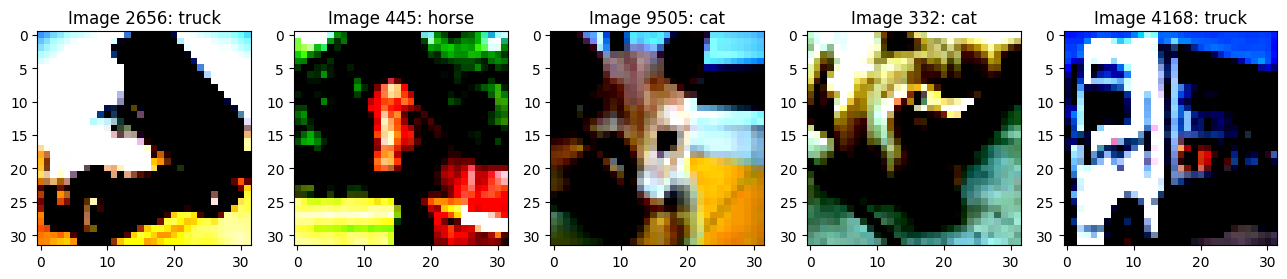

In [ ]:
np.random.seed(123)

random_indices = np.random.choice(len(cifar_test), size=5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(16, 8))

for ax,i in zip(axes, random_indices):
  ax.imshow(torch.permute(cifar_test[i][0], (1,2,0)), cmap="gray")
  ax.set_title(f"Image {i}: {idx_to_class[cifar_test[i][1]]}")

plt.show()

In [ ]:
samples = torch.stack([cifar_test[i][0] for i in random_indices], dim=0)
labels = torch.stack([torch.tensor(cifar_test[i][1]) for i in random_indices], dim=0)

In [ ]:
train_loader = DataLoader(cifar_train, batch_size=64, shuffle=True, num_workers=0)
test_loader = DataLoader(cifar_test, batch_size=64, shuffle=False, num_workers=0)

In [ ]:
torch.manual_seed(123)
model3 = VAE3(3*32*32, 3*32*32, 128)
model3.to(device)

optimizer3 = torch.optim.Adam(model3.parameters(), lr=0.0001)
epochs = 50

total_steps = epochs * len(train_loader)
warmup_steps = int(0.05 * total_steps)  # 5% warmup
# scheduler1 = torch.optim.lr_scheduler.LambdaLR(optimizer1, lr_lambda)

global_step3 = 0
train_losses3, val_losses3 = [], []
train_reconst_losses3, val_reconst_losses3 = [], []
train_dkl_losses3, val_dkl_losses3 = [], []
train_var_decoder_lst3, val_var_decoder_lst3 = [], []
var_grad_norm_lst3 = []
lr_lst3 = []

t5 = time.time()

model3.train()
for epoch in range(epochs):
  for x, _ in train_loader:
    optimizer3.zero_grad()
    x = x.flatten(1)
    loss, _, _, _, _ = calc_batch_loss3(model3, x, device, n_samples=5)
    loss.backward()
    var_grad_norm3 = model3.decoder.log_scale.grad.data.norm()
    var_grad_norm_lst3.append(var_grad_norm3)
    # lr_lst3.append(scheduler1.get_last_lr()[0])
    optimizer3.step()
    # scheduler1.step()
    global_step3 += 1

    if global_step3 % 500 == 0:
      model3.eval()
      train_loss3, train_reconst_loss3, train_dkl3, train_mu_decoder3, train_var_decoder3 = evaluate3(train_loader, model3, device, max_batch=20, n_samples=5)
      val_loss3, val_reconst_loss3, val_dkl3, val_mu_decoder3, val_var_decoder3 = evaluate3(test_loader, model3, device, max_batch=20, n_samples=5)
      model3.train()
      print(f"Epoch: {epoch:3d} \t\t Step: {global_step3:5d}")
      print(f"\t\t\tTrain Loss: {train_loss3}")
      print(f"\t\t\tValidation Loss: {val_loss3}")
      train_losses3.append(train_loss3)
      val_losses3.append(val_loss3)
      train_reconst_losses3.append(train_reconst_loss3)
      val_reconst_losses3.append(val_reconst_loss3)
      train_dkl_losses3.append(train_dkl3)
      val_dkl_losses3.append(val_dkl3)
      train_var_decoder_lst3.append(train_var_decoder3)
      val_var_decoder_lst3.append(val_var_decoder3)
      if global_step3 % 1000 == 0:
        model3.eval()
        flatten_samples = samples.flatten(1)
        reconstructed = sample_from_decoder3(model3, flatten_samples, device, n_samples=1).clamp(0,1).reshape(5, 3, 32, 32).cpu()
        fig, axes = plt.subplots(1, 5, figsize=(16, 8))
        for ax,i in zip(axes, range(5)):
          ax.imshow(torch.permute(reconstructed[i], (1,2,0)))
          ax.set_title(f"Image {i}: {idx_to_class[labels[i].item()]}")
        plt.show()
        model3.train()

t6 = time.time()

print(f"Total training time: {t6-t5}s")

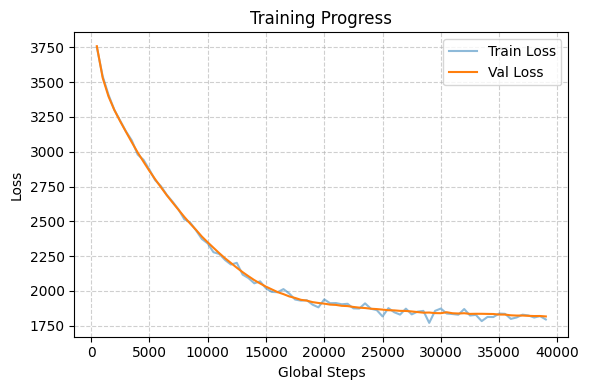

In [ ]:
plot_training_results(train_losses3, val_losses3, 500, title="Training Progress")

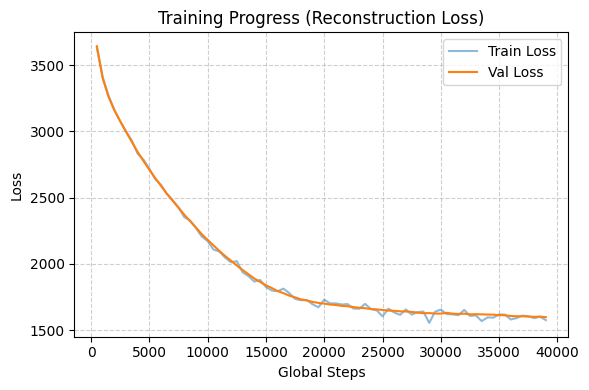

In [ ]:
plot_training_results(train_reconst_losses3, val_reconst_losses3, 500, title="Training Progress (Reconstruction Loss)")

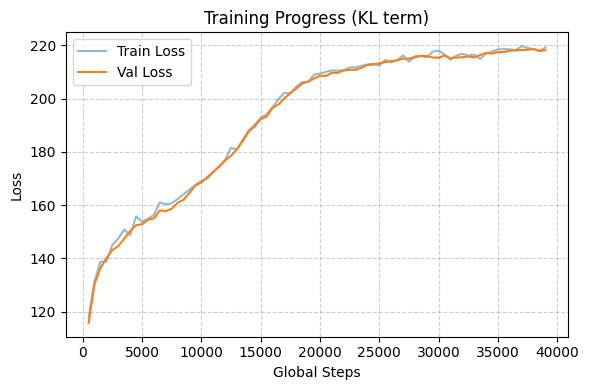

In [ ]:
plot_training_results(train_dkl_losses3, val_dkl_losses3, 500, title="Training Progress (KL term)")

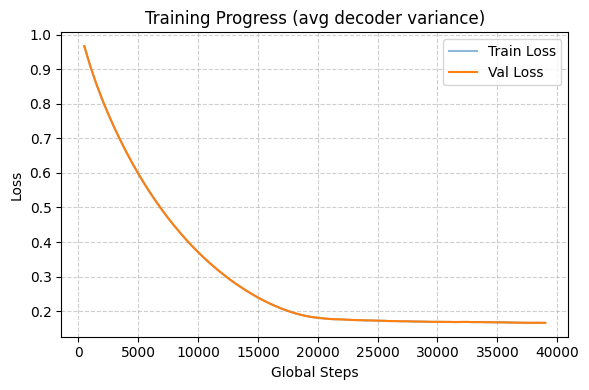

In [ ]:
plot_training_results(train_var_decoder_lst3, val_var_decoder_lst3, 500, title="Training Progress (avg decoder variance)")

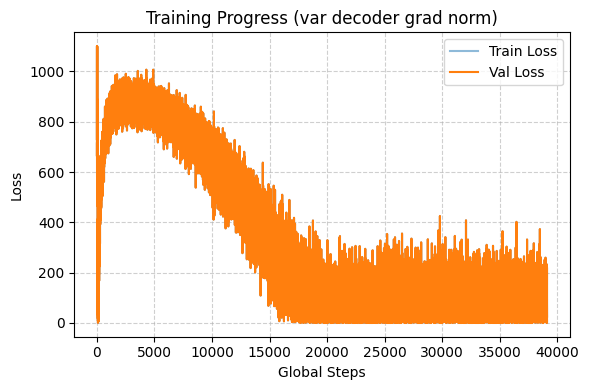

In [ ]:
plot_training_results([var.cpu().numpy() for var in var_grad_norm_lst3], [var.cpu().numpy() for var in var_grad_norm_lst3], 1, title="Training Progress (var decoder grad norm)")


Extracting 32D latents...

Applying t-SNE (this may take a minute)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 10000 samples in 1.322s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 2.397761
[t-SNE] KL divergence after 250 iterations with early exaggeration: 107.303894
[t-SNE] KL divergence after 1000 iterations: 4.571064


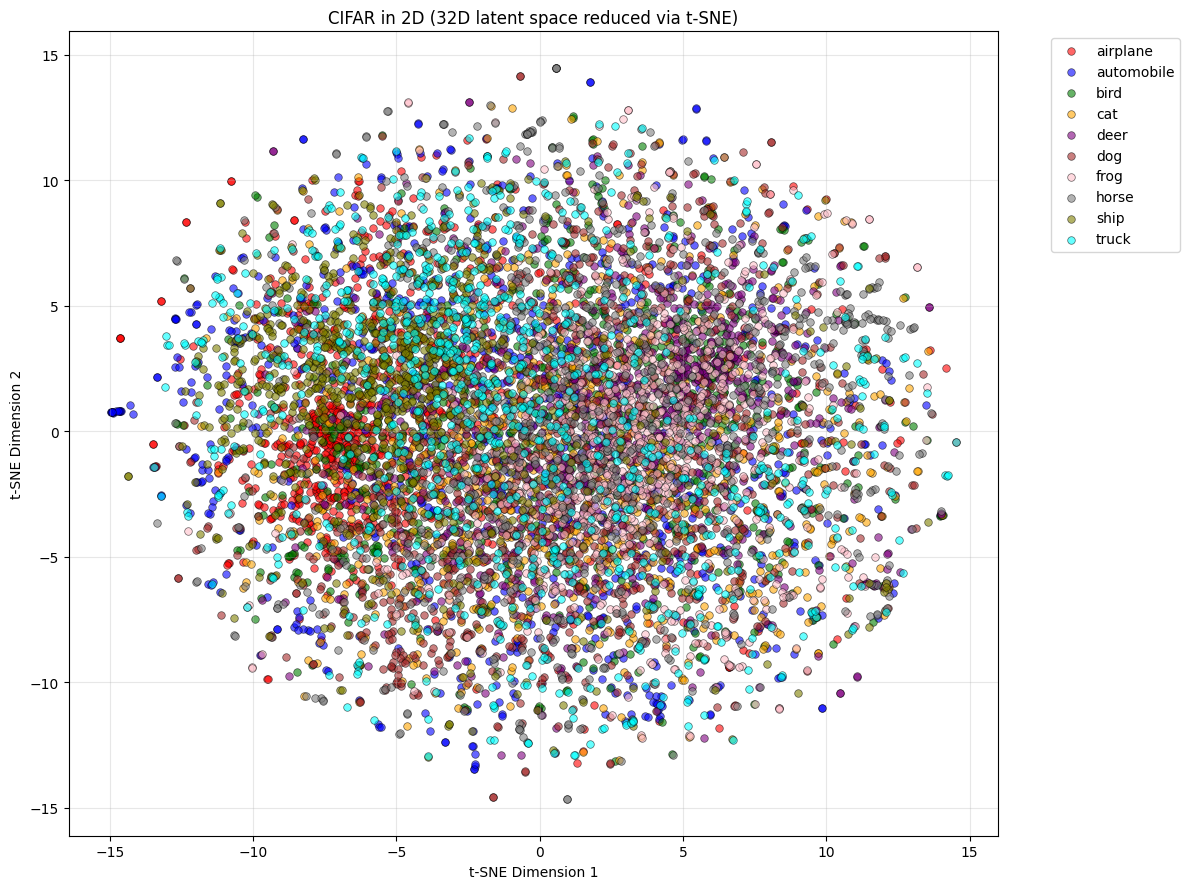


t-SNE visualization complete!
Original latent shape: (10000, 128)
t-SNE reduced shape: (10000, 2)


In [ ]:
# visualizing sampled latent vectors from approximate posterior (probabilistic encoder)

print("\nExtracting 32D latents...")
all_latents = []
all_labels = []

model3.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        img_flatten = images.flatten(1)
        mu_encoder, var_encoder = model3.encoder(img_flatten)
        latents_z = reparameterize(mu_encoder, var_encoder, n_samples=1).squeeze(1) # since only 1 latent vector is sampled, squeezing the dim-1

        all_latents.append(latents_z.cpu().numpy())
        all_labels.append(labels.numpy())

latents_32d = np.vstack(all_latents)
labels = np.concatenate(all_labels)

# Apply t-SNE to reduce 32D to 2D
print("\nApplying t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=1)
latents_2d = tsne.fit_transform(latents_32d)

# Plot
plt.figure(figsize=(12, 9))

# Define colors for each digit (0-9)
colors = ['red', 'blue', 'green', 'orange', 'purple',
          'brown', 'pink', 'gray', 'olive', 'cyan']

# Plot each digit with its own color
for digit in range(10):
    mask = labels == digit
    plt.scatter(latents_2d[mask, 0], latents_2d[mask, 1],
                c=colors[digit], label=f'{idx_to_class[digit]}',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('CIFAR in 2D (32D latent space reduced via t-SNE)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nt-SNE visualization complete!")
print(f"Original latent shape: {latents_32d.shape}")
print(f"t-SNE reduced shape: {latents_2d.shape}")

In [ ]:
for i in range(latents_32d.shape[-1]):
  print(f"Dimension-{i}\t\tMean:{latents_32d[:,i].mean():.3f}\t\tVariance:{latents_32d[:,i].std()**2:.3f}")

Dimension-0		Mean:-0.146		Variance:0.976
Dimension-1		Mean:-0.531		Variance:0.968
Dimension-2		Mean:0.177		Variance:0.976
Dimension-3		Mean:-0.516		Variance:0.966
Dimension-4		Mean:-0.411		Variance:0.999
Dimension-5		Mean:0.288		Variance:0.954
Dimension-6		Mean:-0.005		Variance:0.992
Dimension-7		Mean:-0.138		Variance:0.968
Dimension-8		Mean:-0.092		Variance:0.984
Dimension-9		Mean:0.067		Variance:0.998
Dimension-10		Mean:0.137		Variance:1.019
Dimension-11		Mean:-0.124		Variance:0.906
Dimension-12		Mean:0.088		Variance:1.247
Dimension-13		Mean:-0.048		Variance:1.238
Dimension-14		Mean:-0.045		Variance:0.964
Dimension-15		Mean:-0.027		Variance:1.039
Dimension-16		Mean:0.292		Variance:0.980
Dimension-17		Mean:0.029		Variance:1.232
Dimension-18		Mean:-0.045		Variance:0.942
Dimension-19		Mean:-0.165		Variance:0.847
Dimension-20		Mean:0.190		Variance:1.281
Dimension-21		Mean:-0.031		Variance:0.960
Dimension-22		Mean:-0.146		Variance:0.971
Dimension-23		Mean:-0.185		Variance:0.928
Dimension-

In [ ]:
# interpolating the latents of same digit images and decoding

# first mapping and categorising the latent vector to respective digits
def group_latents_by_label(all_latents, all_labels):
    # Concatenate batches
    latents = np.concatenate(all_latents, axis=0)
    labels = np.concatenate(all_labels, axis=0)

    # Create dict: digit -> list of latents
    latent_dict = {i: [] for i in range(10)}

    for z, y in zip(latents, labels):
        latent_dict[int(y)].append(z)

    # Convert lists to arrays
    for k in latent_dict:
        latent_dict[k] = np.array(latent_dict[k])

    return latent_dict

# interpolation and decoding method
def interpolate_and_decode3(model, z1, z2, steps, device, img_shape):
    """
    z1, z2: tensors of shape (latent_dim,)
    steps: number of interpolation points
    """

    model.eval()

    # Create interpolation coefficients
    alphas = torch.linspace(0, 1, steps, device=device)

    # Store outputs
    samples = []

    with torch.no_grad():
        for alpha in alphas:
            # Linear interpolation in latent space
            z = (1 - alpha) * z1 + alpha * z2
            z = z.unsqueeze(0).unsqueeze(1)  # shape (1, 1, latent_dim)

            # Decode
            mu_decoder, var_decoder = model.decoder(z)

            # Sample from p(x|z)
            eps = torch.randn_like(mu_decoder)
            x_sample = mu_decoder + torch.sqrt(var_decoder) * eps

            # denormalizing
            mean = torch.tensor([0.4914, 0.4822, 0.4465], device=x_sample.device).view(1, 3, 1, 1)
            std  = torch.tensor([0.2023, 0.1994, 0.2010], device=x_sample.device).view(1, 3, 1, 1)

            x_sample = x_sample.reshape(img_shape) * std + mean
            samples.append(x_sample.clamp(0, 1).cpu())

    return torch.cat(samples, dim=0)

# fn for sampling, interpolating, decoding and plotting orchestration
def generate_interpolation_grid3(
    model,
    latent_dict,
    device,
    steps=4,
    img_shape=(28, 28)
):
    model.eval()

    all_rows = []

    for digit in range(10):
        latents = latent_dict[digit]

        # Randomly pick 2 latent vectors
        np.random.seed(101)
        idx = np.random.choice(len(latents), size=2, replace=False)
        z1 = torch.tensor(latents[idx[0]], device=device).float()
        z2 = torch.tensor(latents[idx[1]], device=device).float()

        # 🔹 Use your function here
        samples = interpolate_and_decode3(model, z1, z2, steps, device, img_shape)
        samples = samples.cpu()  # (steps, input_dim)

        # Reshape each sample into image
        row_images = [
            samples[i].permute(1,2,0).numpy()
            for i in range(steps)
        ]

        all_rows.append(row_images)

    # 🔹 Plot grid
    fig, axes = plt.subplots(10, steps, figsize=(steps * 2, 20))

    for i in range(10):
        for j in range(steps):
            axes[i, j].imshow(all_rows[i][j], cmap='gray')
            axes[i, j].axis('off')

            if j == 0:
                axes[i, j].set_ylabel(str(i), fontsize=12)

    plt.tight_layout()
    plt.show()

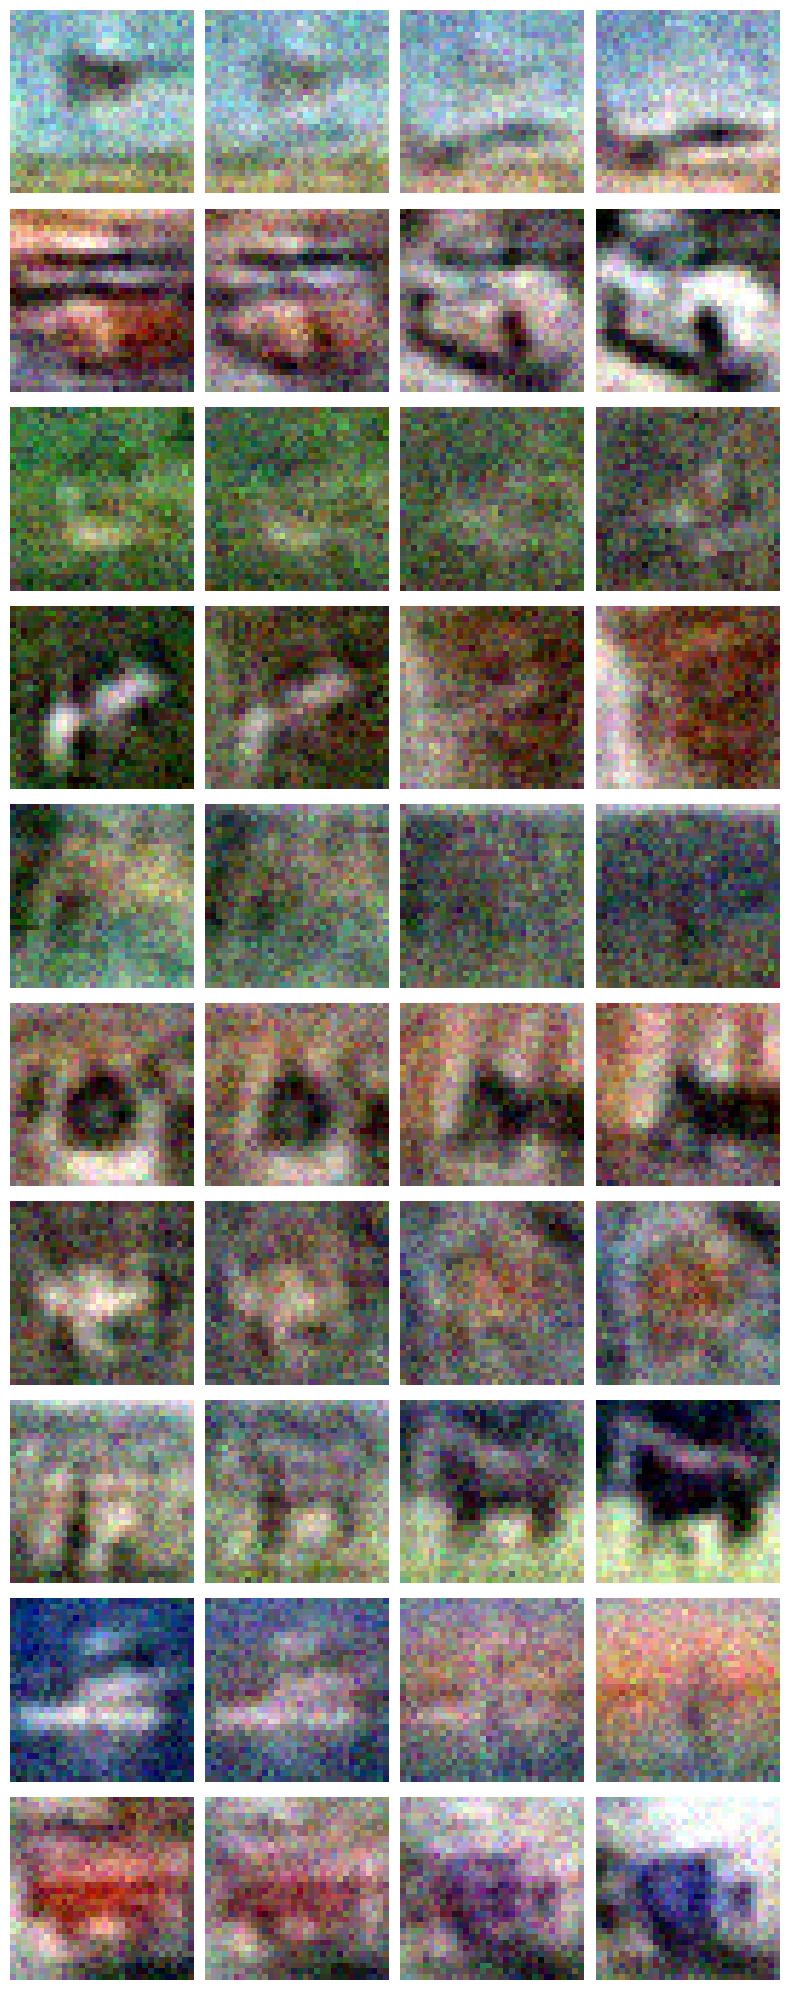

In [ ]:
latent_dict = group_latents_by_label(all_latents, all_labels)

generate_interpolation_grid3(model3, latent_dict, device, img_shape=(3, 32, 32))

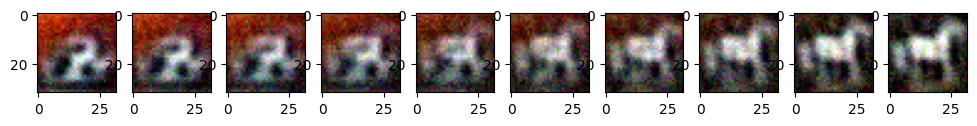

In [ ]:
z1 = torch.tensor(latent_dict[1][0], device=device)
z2 = torch.tensor(latent_dict[7][0], device=device)

interpolated_and_decoded3 = interpolate_and_decode3(model3, z1, z2, steps=10, device=device, img_shape=(3, 32, 32))

fig, axes = plt.subplots(1, 10, figsize=(12, 20))

for i in range(10):
  axes[i].imshow(interpolated_and_decoded3[i].permute(1,2,0).cpu().numpy(), cmap="gray")

plt.show()

Latent: tensor([ 2.2769,  0.3825,  1.2939,  0.3556,  1.1851, -0.7490,  1.5981,  0.4297,
        -0.1653,  0.6285,  1.4933, -1.2005,  0.8003, -0.3150,  1.0319, -0.2678,
         0.5220, -0.0967, -1.1311, -1.0029,  1.2533,  0.1843, -2.3126, -1.9857,
         0.6648,  1.3409,  1.2840,  0.6751, -1.2031,  0.9570, -0.8422,  0.5119,
        -0.9464, -0.8801, -0.0626, -0.7708,  0.2718, -0.7775, -0.9601, -2.0595,
         2.4585, -0.0378, -1.0450, -0.9094,  1.4742,  0.6487,  0.0862,  0.0236,
         1.1151,  1.3162, -1.3975,  0.6440,  0.3501, -0.8166, -0.6043, -1.0245,
        -0.2952,  1.1734, -0.7511,  0.1590,  0.6767, -0.1015,  0.4667, -0.1294,
         0.5710,  0.7497, -0.4419,  1.2184,  1.6600, -0.4514,  1.5404, -1.8048,
         0.9441,  0.2397,  1.7892, -0.7618, -0.4739,  1.5714,  1.5054, -1.8104,
         1.7544,  0.4203, -0.0383,  0.6251,  0.9813,  0.5671,  0.0926,  0.6745,
        -0.7752,  0.5121, -0.2312, -1.4907,  0.0526,  0.2691,  1.6786,  0.4421,
        -1.9161,  1.7818,  1.263

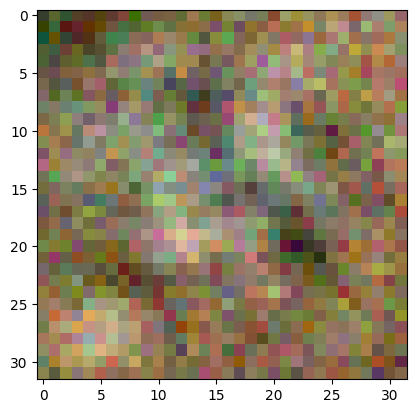

In [ ]:
# randomly sampling latent from prior (standard normal distribution) and decoding
latent_dim = 128
standard_normal_mean = torch.zeros(latent_dim, device=device)
standard_normal_std = torch.ones(latent_dim, device=device)
eps1 = torch.randn_like(standard_normal_mean, device=device)

sampled_latent_z = standard_normal_mean + standard_normal_std * eps1

print(f"Latent: {sampled_latent_z}")

model3.eval()
with torch.no_grad():
  mu_decoder, var_decoder = model3.decoder(eps1.unsqueeze(0).unsqueeze(1))
  eps2 = torch.randn_like(mu_decoder, device=device)
  reconstructed_sample = mu_decoder + torch.sqrt(var_decoder) * eps2
  mean = torch.tensor([0.4914, 0.4822, 0.4465], device=reconstructed_sample.device).view(3, 1, 1)
  std  = torch.tensor([0.2023, 0.1994, 0.2010], device=reconstructed_sample.device).view(3, 1, 1)
  reconstructed_sample = reconstructed_sample.reshape(3, 32, 32) * std + mean
  reconstructed_sample = reconstructed_sample.permute(1,2,0).cpu().numpy()  # doing reshape(32,32,3) is wrong here

plt.imshow(reconstructed_sample, cmap="gray")
plt.show()

# **MNIST - Bernoulli VAE**

In [ ]:
# bernoulli VAE implementation
class encoder2(nn.Module):
  def __init__(self, inp_size, latent_dim):
    super().__init__()
    self.hidden_layer = nn.Linear(inp_size, 256, bias=True)
    self.relu = nn.ReLU()
    self.mean_ = nn.Linear(256,latent_dim, bias=True)
    self.log_var = nn.Linear(256,latent_dim, bias=True)

  def forward(self, x):
    N, _ = x.shape
    h = self.relu(self.hidden_layer(x))
    mu = self.mean_(h)
    log_var = self.log_var(h)
    var = torch.exp(log_var)
    return mu, var

def reparameterize(mu, var):
    eps = torch.randn_like(mu).to(mu.device)
    return mu + eps * torch.sqrt(var)

class decoder2(nn.Module):
  def __init__(self, output_size, latent_dim):
    super().__init__()
    self.hidden_layer1 = nn.Linear(latent_dim, 256, bias=True)
    self.relu = nn.ReLU()
    self.hidden_layer2 = nn.Linear(256, output_size, bias=True)
    self.sigmoid = nn.Sigmoid()

  def forward(self, latent_z):
    h1 = self.relu(self.hidden_layer1(latent_z))
    reconst = self.sigmoid(self.hidden_layer2(h1))
    return reconst

class VAE2(nn.Module):
  def __init__(self, inp_size, output_size, latent_dim):
    super().__init__()
    self.encoder = encoder2(inp_size, latent_dim)
    self.decoder = decoder2(output_size, latent_dim)

  def forward(self, x):
    mu_encoder, var_encoder = self.encoder(x)
    latent_z = reparameterize(mu_encoder, var_encoder)
    reconst = self.decoder(latent_z)

    return mu_encoder, var_encoder, reconst

In [ ]:
def calc_batch_loss2(model, x, device):
  x = x.to(device)
  mu_encoder, var_encoder, reconst = model(x)
  dkl = torch.sum(1+torch.log(var_encoder)-torch.square(mu_encoder)-var_encoder, dim=-1).mean() * (-1/2)
  reconst_loss = nn.functional.binary_cross_entropy(reconst, x, reduction='sum')/x.shape[0]
  loss = reconst_loss + dkl
  return loss, reconst_loss, dkl

In [ ]:
def evaluate2(loader, model, device, max_batch=5):
  total_loss = 0
  total_reconst_loss, total_dkl = 0, 0
  if max_batch <= 0:
    return float("nan")
  elif max_batch is None:
    max_batch = len(loader)
  else:
    max_batch = min(max_batch, len(loader))

  for i, (x, _) in enumerate(loader):
    if i < max_batch:
      with torch.no_grad():
        x = x.flatten(1)
        loss, reconst_loss, dkl = calc_batch_loss2(model, x, device)
      total_loss += loss.item()
      total_reconst_loss += reconst_loss.item()
      total_dkl += dkl.item()
    else:
      break

  return total_loss/max_batch, total_reconst_loss/max_batch, total_dkl/max_batch

In [ ]:
def sample_from_decoder2(model, x, device):
  x = x.to(device)
  with torch.no_grad():
    mu_encoder, var_encoder, reconst = model(x)
  return reconst

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:
mnist_train2 = MNIST(
    root="/content/drive/My Drive/PyTorch Exercise",
    train=True,
    download=True,
    transform=transform
    )

mnist_test2 = MNIST(
    root="/content/drive/My Drive/PyTorch Exercise",
    train=False,
    download=True,
    transform=transform
    )

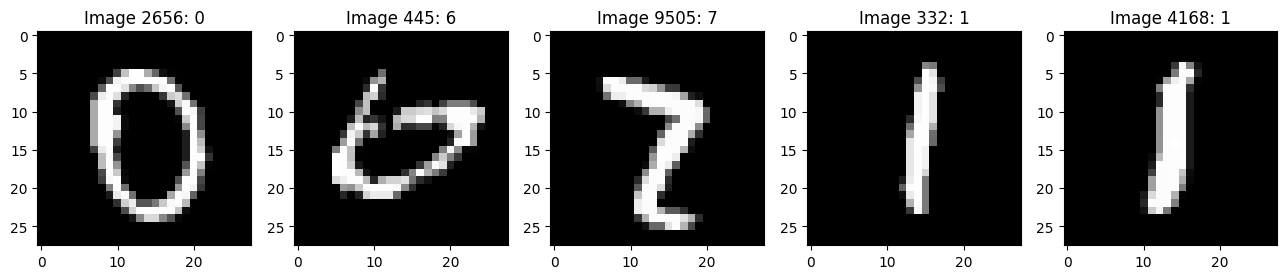

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(123)

random_indices = np.random.choice(len(mnist_test2), size=5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(16, 8))

for ax,i in zip(axes, random_indices):
  ax.imshow(mnist_test2[i][0].squeeze(), cmap="gray")
  ax.set_title(f"Image {i}: {mnist_test2[i][1]}")

plt.show()

In [ ]:
samples = torch.stack([mnist_test2[i][0] for i in random_indices], dim=0)
labels = torch.stack([torch.tensor(mnist_test2[i][1]) for i in random_indices], dim=0)

In [ ]:
train_loader2 = DataLoader(mnist_train2, batch_size=64, shuffle=True, num_workers=0)
test_loader2 = DataLoader(mnist_test2, batch_size=64, shuffle=False, num_workers=0)

In [ ]:
torch.manual_seed(123)
model2 = VAE2(28*28, 28*28, 32)
model2.to(device)

optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.0001)
epochs = 50
global_step2 = 0
train_losses2, val_losses2 = [], []
train_reconst_losses2, val_reconst_losses2 = [], []
train_dkl_losses2, val_dkl_losses2 = [], []

t3 = time.time()

model2.train()
for epoch in range(epochs):
  for x, _ in train_loader2:
    optimizer2.zero_grad()
    x = x.flatten(1)
    loss, _, _ = calc_batch_loss2(model2, x, device)
    loss.backward()
    optimizer2.step()
    global_step2 += 1

    if global_step2 % 500 == 0:
      model2.eval()
      train_loss2, train_reconst_loss2, train_dkl2 = evaluate2(train_loader2, model2, device, max_batch=20)
      val_loss2, val_reconst_loss2, val_dkl2 = evaluate2(test_loader2, model2, device, max_batch=20)
      model2.train()
      print(f"Epoch: {epoch:3d} \t\t Step: {global_step2:5d}")
      print(f"\t\t\tTrain Loss: {train_loss2}")
      print(f"\t\t\tValidation Loss: {val_loss2}")
      train_losses2.append(train_loss2)
      val_losses2.append(val_loss2)
      train_reconst_losses2.append(train_reconst_loss2)
      val_reconst_losses2.append(val_reconst_loss2)
      train_dkl_losses2.append(train_dkl2)
      val_dkl_losses2.append(val_dkl2)
      if global_step2 % 1000 == 0:
        model2.eval()
        flatten_samples = samples.flatten(1)
        reconstructed = sample_from_decoder2(model2, flatten_samples, device).reshape(5, 1, 28, 28).cpu().numpy()
        fig, axes = plt.subplots(1, 5, figsize=(16, 8))
        for ax,i in zip(axes, range(5)):
          ax.imshow(reconstructed[i].squeeze(), cmap="gray")
          ax.set_title(f"Image {i}: {labels[i]}")
        plt.show()
        model2.train()

t4 = time.time()

print(f"Total training time: {t4-t3}s")

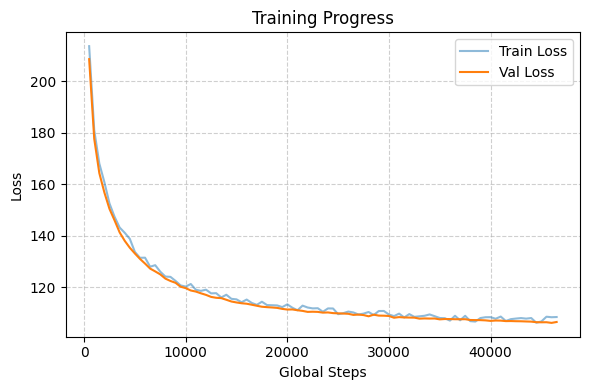

In [ ]:
plot_training_results(train_losses2, val_losses2, 500, title="Training Progress")

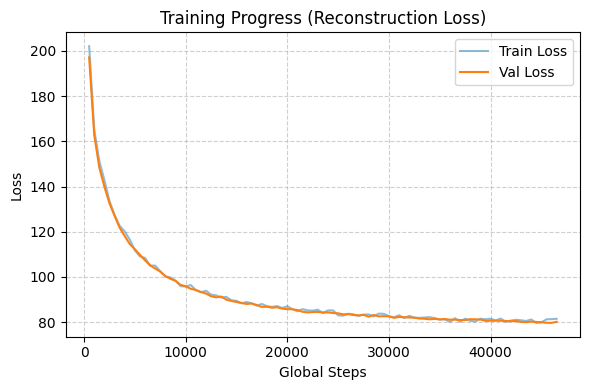

In [ ]:
plot_training_results(train_reconst_losses2, val_reconst_losses2, 500, title="Training Progress (Reconstruction Loss)")

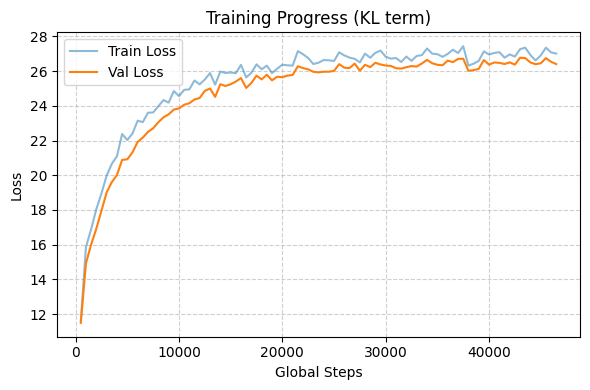

In [ ]:
plot_training_results(train_dkl_losses2, val_dkl_losses2, 500, title="Training Progress (KL term)")


Extracting 32D latents...

Applying t-SNE (this may take a minute)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 10000 samples in 1.365s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 8.529042
[t-SNE] KL divergence after 250 iterations with early exaggeration: 91.633644
[t-SNE] KL divergence after 1000 iterations: 2.194623


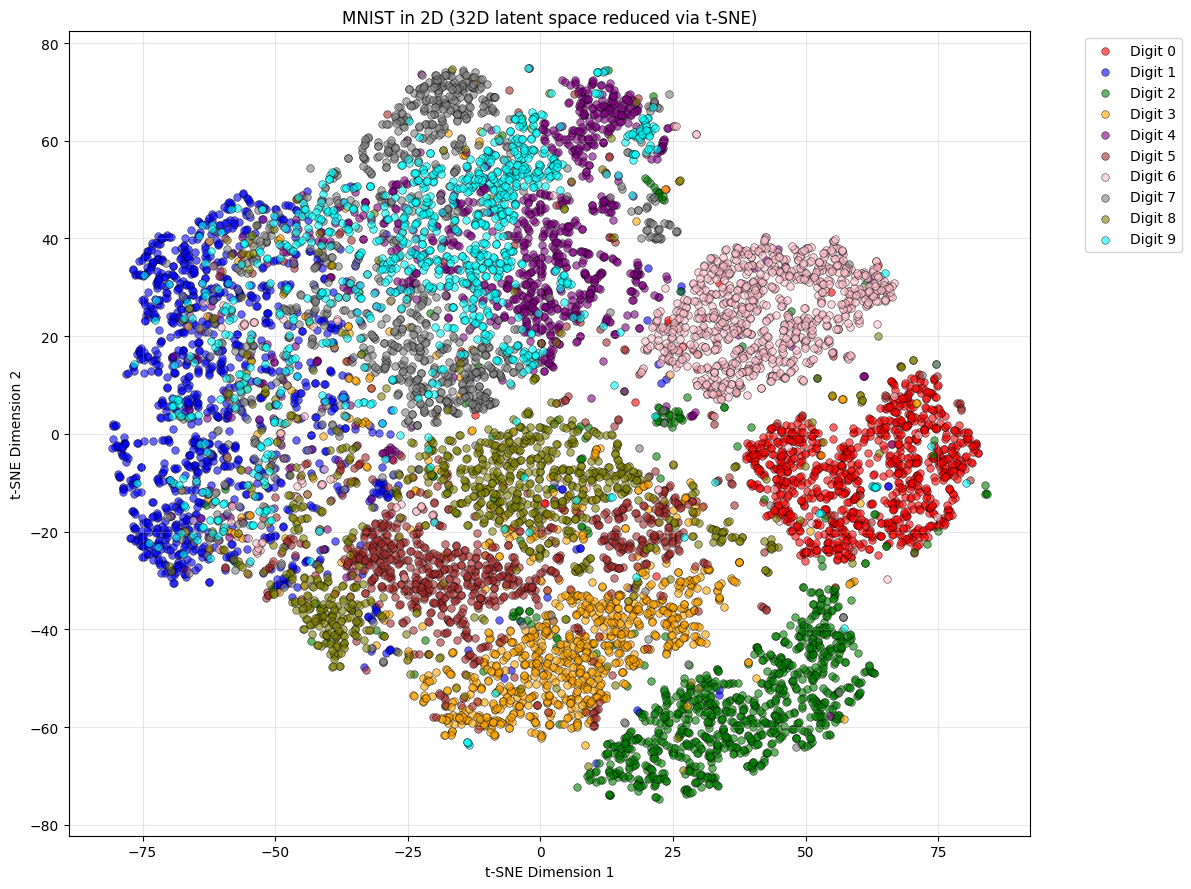


t-SNE visualization complete!
Original latent shape: (10000, 32)
t-SNE reduced shape: (10000, 2)


In [ ]:
# visualizing sampled latent vectors from approximate posterior (probabilistic encoder)

print("\nExtracting 32D latents...")
all_latents = []
all_labels = []

model2.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        img_flatten = images.flatten(1)
        mu_encoder, var_encoder = model2.encoder(img_flatten)
        latents_z = reparameterize(mu_encoder, var_encoder)

        all_latents.append(latents_z.cpu().numpy())
        all_labels.append(labels.numpy())

latents_32d = np.vstack(all_latents)
labels = np.concatenate(all_labels)

# Apply t-SNE to reduce 32D to 2D
print("\nApplying t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=1)
latents_2d = tsne.fit_transform(latents_32d)

# Plot
plt.figure(figsize=(12, 9))

# Define colors for each digit (0-9)
colors = ['red', 'blue', 'green', 'orange', 'purple',
          'brown', 'pink', 'gray', 'olive', 'cyan']

# Plot each digit with its own color
for digit in range(10):
    mask = labels == digit
    plt.scatter(latents_2d[mask, 0], latents_2d[mask, 1],
                c=colors[digit], label=f'Digit {digit}',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('MNIST in 2D (32D latent space reduced via t-SNE)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nt-SNE visualization complete!")
print(f"Original latent shape: {latents_32d.shape}")
print(f"t-SNE reduced shape: {latents_2d.shape}")

In [ ]:
for i in range(latents_32d.shape[-1]):
  print(f"Dimension-{i}\t\tMean:{latents_32d[:,i].mean():.3f}\t\tVariance:{latents_32d[:,i].std()**2:.3f}")

Dimension-0		Mean:4.304		Variance:28.821
Dimension-1		Mean:-8.113		Variance:43.257
Dimension-2		Mean:-0.315		Variance:151.926
Dimension-3		Mean:4.803		Variance:312.547
Dimension-4		Mean:-3.492		Variance:15.314
Dimension-5		Mean:2.150		Variance:1.805
Dimension-6		Mean:7.838		Variance:101.835
Dimension-7		Mean:-2.162		Variance:28.593
Dimension-8		Mean:-2.980		Variance:19.266
Dimension-9		Mean:-2.281		Variance:536.019
Dimension-10		Mean:-1.111		Variance:226.955
Dimension-11		Mean:-4.140		Variance:29.926
Dimension-12		Mean:0.044		Variance:1.031
Dimension-13		Mean:3.441		Variance:57.574
Dimension-14		Mean:6.928		Variance:62.858
Dimension-15		Mean:-4.668		Variance:45.180
Dimension-16		Mean:-2.159		Variance:6.353
Dimension-17		Mean:2.979		Variance:20.083
Dimension-18		Mean:-1.767		Variance:1.671
Dimension-19		Mean:0.697		Variance:89.979
Dimension-20		Mean:-0.888		Variance:1.414
Dimension-21		Mean:1.229		Variance:17.415
Dimension-22		Mean:6.448		Variance:76.308
Dimension-23		Mean:-2.660		Varia

In [ ]:
# interpolating the latents of same digit images and decoding

# first mapping and categorising the latent vector to respective digits
def group_latents_by_label(all_latents, all_labels):
    # Concatenate batches
    latents = np.concatenate(all_latents, axis=0)
    labels = np.concatenate(all_labels, axis=0)

    # Create dict: digit -> list of latents
    latent_dict = {i: [] for i in range(10)}

    for z, y in zip(latents, labels):
        latent_dict[int(y)].append(z)

    # Convert lists to arrays
    for k in latent_dict:
        latent_dict[k] = np.array(latent_dict[k])

    return latent_dict

# interpolation and decoding method
def interpolate_and_decode2(model, z1, z2, steps, device):
    """
    z1, z2: tensors of shape (latent_dim,)
    steps: number of interpolation points
    """

    model.eval()

    # Create interpolation coefficients
    alphas = torch.linspace(0, 1, steps, device=device)

    # Store outputs
    samples = []

    with torch.no_grad():
        for alpha in alphas:
            # Linear interpolation in latent space
            z = (1 - alpha) * z1 + alpha * z2
            z = z.unsqueeze(0)  # shape (1, latent_dim)

            # Decode
            x_sample = model.decoder(z)

            samples.append(x_sample.cpu())

    return torch.cat(samples, dim=0)

# fn for sampling, interpolating, decoding and plotting orchestration
def generate_interpolation_grid2(
    model,
    latent_dict,
    device,
    steps=4,
    img_shape=(28, 28)
):
    model.eval()

    all_rows = []

    for digit in range(10):
        latents = latent_dict[digit]

        # Randomly pick 2 latent vectors
        idx = np.random.choice(len(latents), size=2, replace=False)
        z1 = torch.tensor(latents[idx[0]], device=device).float()
        z2 = torch.tensor(latents[idx[1]], device=device).float()

        # 🔹 Use your function here
        samples = interpolate_and_decode2(model, z1, z2, steps, device)
        samples = samples.cpu().numpy()  # (steps, input_dim)

        # Reshape each sample into image
        row_images = [
            samples[i].reshape(img_shape)
            for i in range(steps)
        ]

        all_rows.append(row_images)

    # 🔹 Plot grid
    fig, axes = plt.subplots(10, steps, figsize=(steps * 2, 20))

    for i in range(10):
        for j in range(steps):
            axes[i, j].imshow(all_rows[i][j], cmap='gray')
            axes[i, j].axis('off')

            if j == 0:
                axes[i, j].set_ylabel(str(i), fontsize=12)

    plt.tight_layout()
    plt.show()

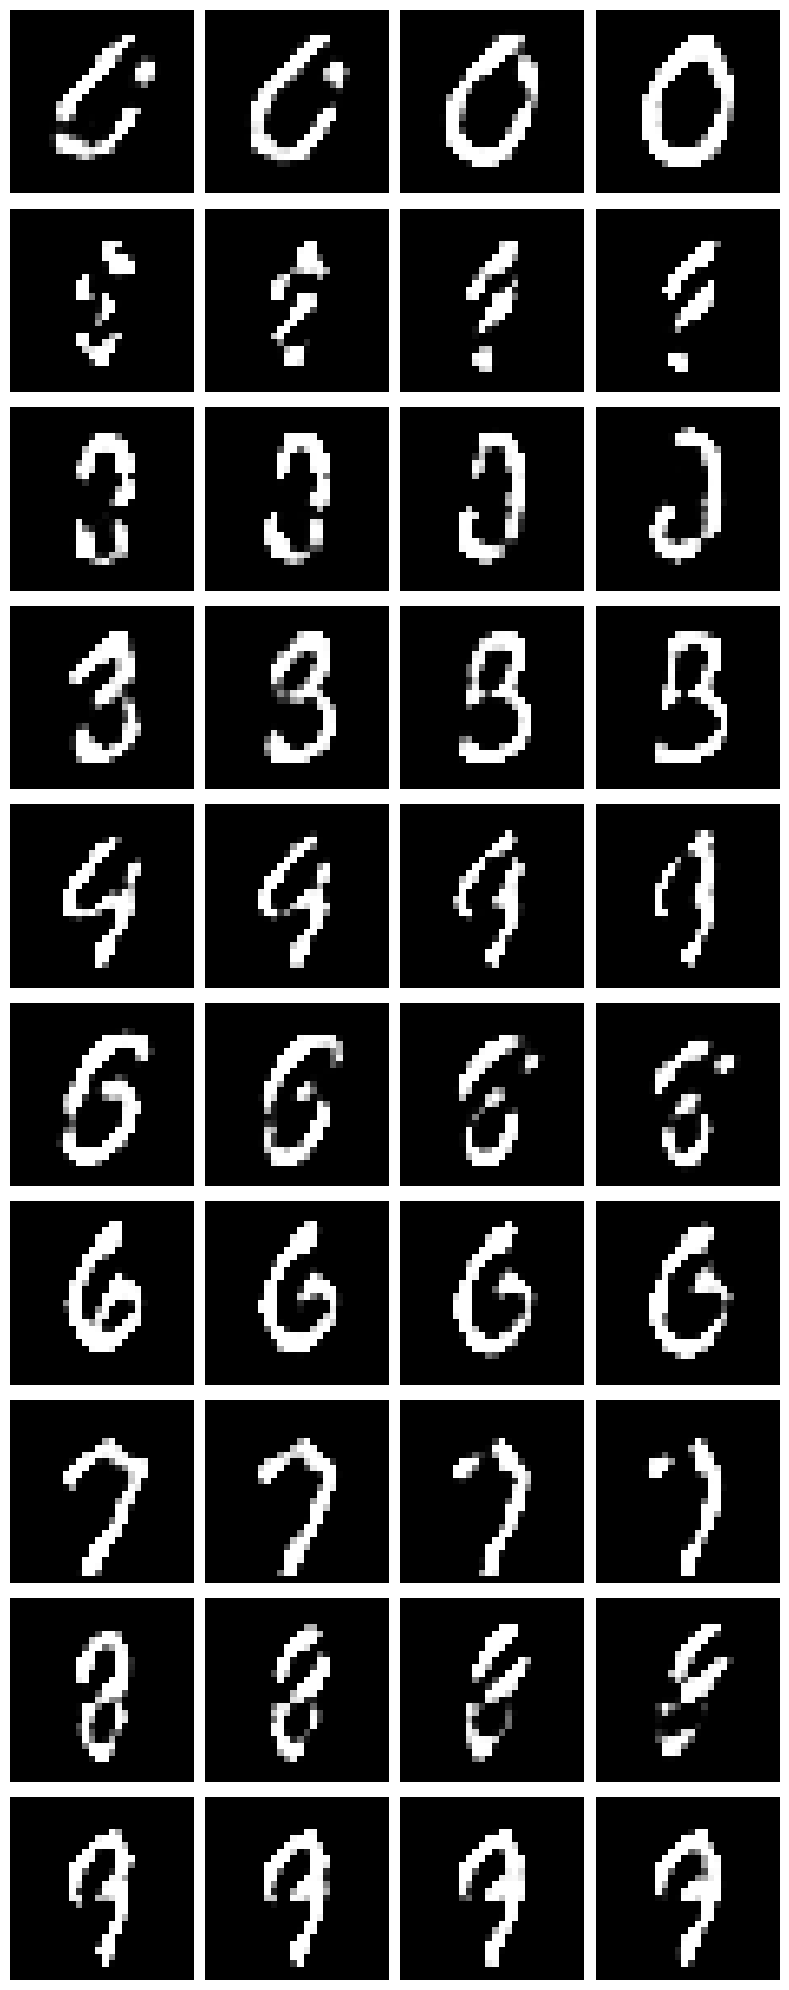

In [ ]:
latent_dict = group_latents_by_label(all_latents, all_labels)

generate_interpolation_grid2(model2, latent_dict, device)

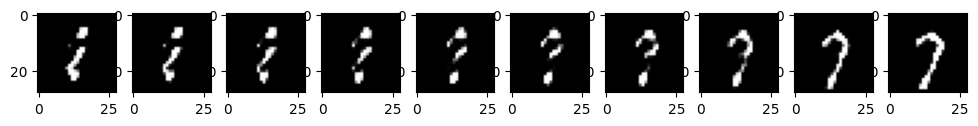

In [ ]:
z1 = torch.tensor(latent_dict[1][0], device=device)
z2 = torch.tensor(latent_dict[7][0], device=device)

interpolated_and_decoded2 = interpolate_and_decode2(model2, z1, z2, steps=10, device=device)

fig, axes = plt.subplots(1, 10, figsize=(12, 20))

for i in range(10):
  axes[i].imshow(interpolated_and_decoded2[i].reshape(28, 28).cpu().numpy(), cmap="gray")

plt.show()

Latent: tensor([ 0.9116, -2.4516, -0.8823, -0.0385,  0.8384, -1.2851,  0.7906,  0.0690,
         0.3104, -1.1977, -1.9079,  1.3999,  0.1780,  0.8066,  0.7107,  0.7537,
         0.1664, -1.4952, -0.2412, -0.6265,  0.9343,  0.0770,  0.0203,  0.6570,
        -0.1455,  0.1186, -0.4466, -0.5937, -0.0119,  0.2187,  1.4876, -0.2073],
       device='cuda:0')


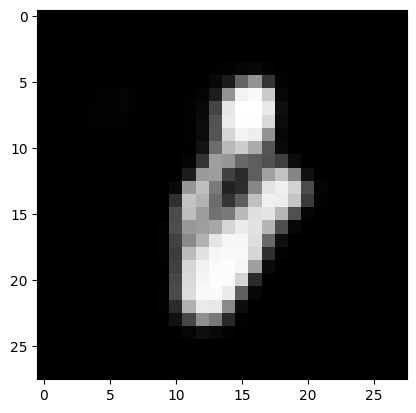

In [ ]:
# randomly sampling latent from prior (standard normal distribution) and decoding
latent_dim = 32
standard_normal_mean = torch.zeros(32, device=device)
standard_normal_std = torch.ones(32, device=device)
eps1 = torch.randn_like(standard_normal_mean, device=device)

sampled_latent_z = standard_normal_mean + standard_normal_std * eps1

print(f"Latent: {sampled_latent_z}")

model2.eval()
with torch.no_grad():
  reconstructed_sample = model2.decoder(eps1.unsqueeze(0))
  reconstructed_sample = reconstructed_sample.reshape(28, 28).cpu().numpy()

plt.imshow(reconstructed_sample, cmap="gray")
plt.show()

# **CIFAR - Bernoulli VAE**

In [ ]:
# bernoulli VAE implementation
class encoder4(nn.Module):
  def __init__(self, inp_size, latent_dim):
    super().__init__()
    self.hidden_layer = nn.Linear(inp_size, 256, bias=True)
    self.relu = nn.ReLU()
    self.mean_ = nn.Linear(256,latent_dim, bias=True)
    self.log_var = nn.Linear(256,latent_dim, bias=True)

  def forward(self, x):
    N, _ = x.shape
    h = self.relu(self.hidden_layer(x))
    mu = self.mean_(h)
    log_var = self.log_var(h)
    var = torch.exp(log_var)
    return mu, var

def reparameterize(mu, var, n_samples):
    # mu, var: (B, D)
    B, D = mu.shape
    eps = torch.randn(B, n_samples, D, device=mu.device)
    std = torch.sqrt(var).unsqueeze(1)  # (B, 1, D)
    z = mu.unsqueeze(1) + eps * std     # (B, n_samples, D)
    return z

class decoder4(nn.Module):
  def __init__(self, output_size, latent_dim):
    super().__init__()
    self.hidden_layer1 = nn.Linear(latent_dim, 256, bias=True)
    self.relu = nn.ReLU()
    self.hidden_layer2 = nn.Linear(256, output_size, bias=True)
    self.sigmoid = nn.Sigmoid()

  def forward(self, latent_z):
    # latent_z: (B, n_samples, D)
    B, n_samples, D = latent_z.shape
    z = latent_z.reshape(B * n_samples, D)
    h1 = self.relu(self.hidden_layer1(z))
    h2 = self.sigmoid(self.hidden_layer2(h1))
    reconst = h2.reshape(B, n_samples, -1)
    return reconst

class VAE4(nn.Module):
  def __init__(self, inp_size, output_size, latent_dim):
    super().__init__()
    self.encoder = encoder4(inp_size, latent_dim)
    self.decoder = decoder4(output_size, latent_dim)

  def forward(self, x, n_samples=1):
    mu_encoder, var_encoder = self.encoder(x)
    latent_z = reparameterize(mu_encoder, var_encoder, n_samples)
    reconst = self.decoder(latent_z)

    return mu_encoder, var_encoder, reconst

In [ ]:
def calc_batch_loss4(model, x, device, n_samples=5):
  x = x.to(device)
  mu_encoder, var_encoder, reconst = model(x, n_samples)
  dkl = torch.sum(1 + torch.log(var_encoder) - torch.square(mu_encoder) - var_encoder, dim=-1).mean() * (-1/2)
  # Expand x → (B, 1, D)
  x_exp = x.unsqueeze(1)
  # BCE per element → (B, n_samples, D)
  bce = nn.functional.binary_cross_entropy(
      reconst,
      x_exp.expand_as(reconst),
      reduction='none'
  )
  # sum over D → (B, n_samples)
  bce = bce.sum(dim=-1)
  # average over samples → (B,)
  bce = bce.mean(dim=1)
  # batch mean
  reconst_loss = bce.mean()
  loss = reconst_loss + dkl
  return loss, reconst_loss, dkl

In [ ]:
def evaluate4(loader, model, device, max_batch=5, n_samples=5):
  total_loss = 0
  total_reconst_loss, total_dkl = 0, 0

  if max_batch <= 0:
    return float("nan")
  elif max_batch is None:
    max_batch = len(loader)
  else:
    max_batch = min(max_batch, len(loader))

  for i, (x, _) in enumerate(loader):
    if i < max_batch:
      with torch.no_grad():
        x = x.flatten(1)
        loss, reconst_loss, dkl = calc_batch_loss4(model, x, device, n_samples)
      total_loss += loss.item()
      total_reconst_loss += reconst_loss.item()
      total_dkl += dkl.item()
    else:
      break

  return total_loss/max_batch, total_reconst_loss/max_batch, total_dkl/max_batch

In [ ]:
def sample_from_decoder4(model, x, device, n_samples=1):
  x = x.to(device)
  with torch.no_grad():
    mu_encoder, var_encoder, reconst = model(x, n_samples=n_samples)
  return reconst

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:
cifar_train = CIFAR10(
    root="/content/drive/My Drive/GenAI/Data",
    train=True,
    download=True,
    transform=transform
    )

cifar_test = CIFAR10(
    root="/content/drive/My Drive/GenAI/Data",
    train=False,
    download=True,
    transform=transform
    )

In [ ]:
print(f"Train size: {len(cifar_train)}")
print(f"Test size: {len(cifar_test)}")
print(f"Image shape: {cifar_train[0][0].shape}")

Train size: 50000
Test size: 10000
Image shape: torch.Size([3, 32, 32])


In [ ]:
cifar_train[0][0].max(), cifar_train[0][0].min(), cifar_train[0][0].unique().numel()

(tensor(1.), tensor(0.), 248)

In [ ]:
cifar_train.class_to_idx

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

In [ ]:
idx_to_class = {v:k for k,v in cifar_train.class_to_idx.items()}

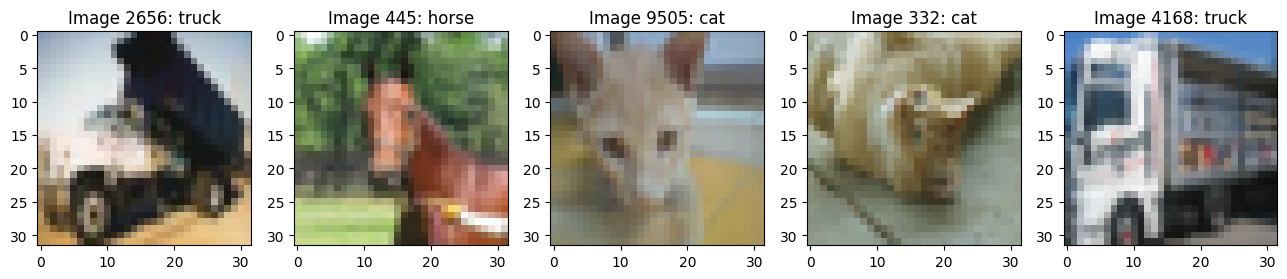

In [ ]:
np.random.seed(123)

random_indices = np.random.choice(len(cifar_test), size=5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(16, 8))

for ax,i in zip(axes, random_indices):
  ax.imshow(torch.permute(cifar_test[i][0], (1,2,0)), cmap="gray")
  ax.set_title(f"Image {i}: {idx_to_class[cifar_test[i][1]]}")

plt.show()

In [ ]:
samples = torch.stack([cifar_test[i][0] for i in random_indices], dim=0)
labels = torch.stack([torch.tensor(cifar_test[i][1]) for i in random_indices], dim=0)

In [ ]:
train_loader = DataLoader(cifar_train, batch_size=64, shuffle=True, num_workers=0)
test_loader = DataLoader(cifar_test, batch_size=64, shuffle=False, num_workers=0)

In [ ]:
torch.manual_seed(123)
model4 = VAE4(3*32*32, 3*32*32, 128)
model4.to(device)

optimizer4 = torch.optim.Adam(model4.parameters(), lr=0.0001)
epochs = 50

# total_steps = epochs * len(train_loader)
# warmup_steps = int(0.05 * total_steps)  # 5% warmup
# scheduler1 = torch.optim.lr_scheduler.LambdaLR(optimizer1, lr_lambda)

global_step4 = 0
train_losses4, val_losses4 = [], []
train_reconst_losses4, val_reconst_losses4 = [], []
train_dkl_losses4, val_dkl_losses4 = [], []
lr_lst4 = []

t7 = time.time()

model4.train()
for epoch in range(epochs):
  for x, _ in train_loader:
    optimizer4.zero_grad()
    x = x.flatten(1)
    loss, _, _ = calc_batch_loss4(model4, x, device, n_samples=5)
    loss.backward()
    # lr_lst4.append(scheduler4.get_last_lr()[0])
    optimizer4.step()
    # scheduler4.step()
    global_step4 += 1

    if global_step4 % 500 == 0:
      model4.eval()
      train_loss4, train_reconst_loss4, train_dkl4 = evaluate4(train_loader, model4, device, max_batch=20, n_samples=5)
      val_loss4, val_reconst_loss4, val_dkl4 = evaluate4(test_loader, model4, device, max_batch=20, n_samples=5)
      model4.train()
      print(f"Epoch: {epoch:3d} \t\t Step: {global_step4:5d}")
      print(f"\t\t\tTrain Loss: {train_loss4}")
      print(f"\t\t\tValidation Loss: {val_loss4}")
      train_losses4.append(train_loss4)
      val_losses4.append(val_loss4)
      train_reconst_losses4.append(train_reconst_loss4)
      val_reconst_losses4.append(val_reconst_loss4)
      train_dkl_losses4.append(train_dkl4)
      val_dkl_losses4.append(val_dkl4)
      if global_step4 % 1000 == 0:
        model4.eval()
        flatten_samples = samples.flatten(1)
        reconstructed = sample_from_decoder4(model4, flatten_samples, device, n_samples=1).reshape(5, 3, 32, 32).cpu()
        fig, axes = plt.subplots(1, 5, figsize=(16, 8))
        for ax,i in zip(axes, range(5)):
          ax.imshow(torch.permute(reconstructed[i], (1,2,0)))
          ax.set_title(f"Image {i}: {idx_to_class[labels[i].item()]}")
        plt.show()
        model4.train()

t8 = time.time()

print(f"Total training time: {t8-t7}s")

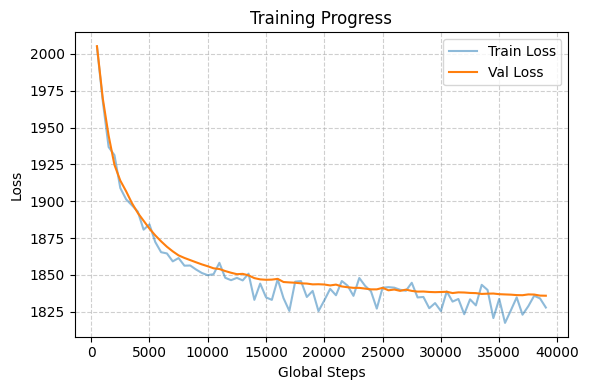

In [ ]:
plot_training_results(train_losses4, val_losses4, 500, title="Training Progress")

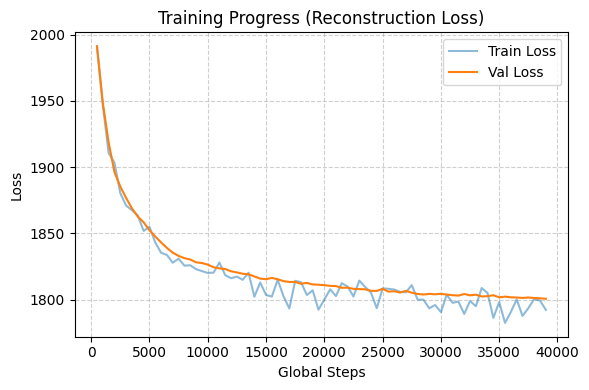

In [ ]:
plot_training_results(train_reconst_losses4, val_reconst_losses4, 500, title="Training Progress (Reconstruction Loss)")

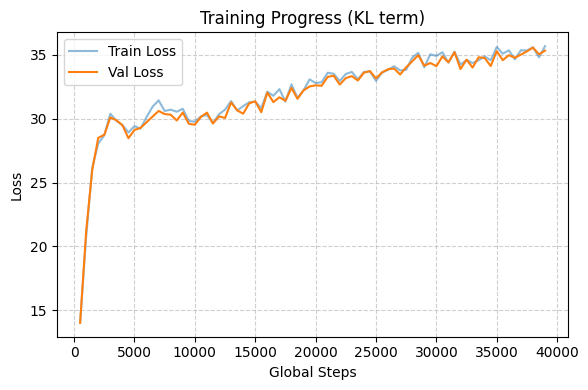

In [ ]:
plot_training_results(train_dkl_losses4, val_dkl_losses4, 500, title="Training Progress (KL term)")


Extracting 32D latents...

Applying t-SNE (this may take a minute)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 10000 samples in 1.636s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 2.507055
[t-SNE] KL divergence after 250 iterations with early exaggeration: 95.880821
[t-SNE] KL divergence after 1000 iterations: 4.885853


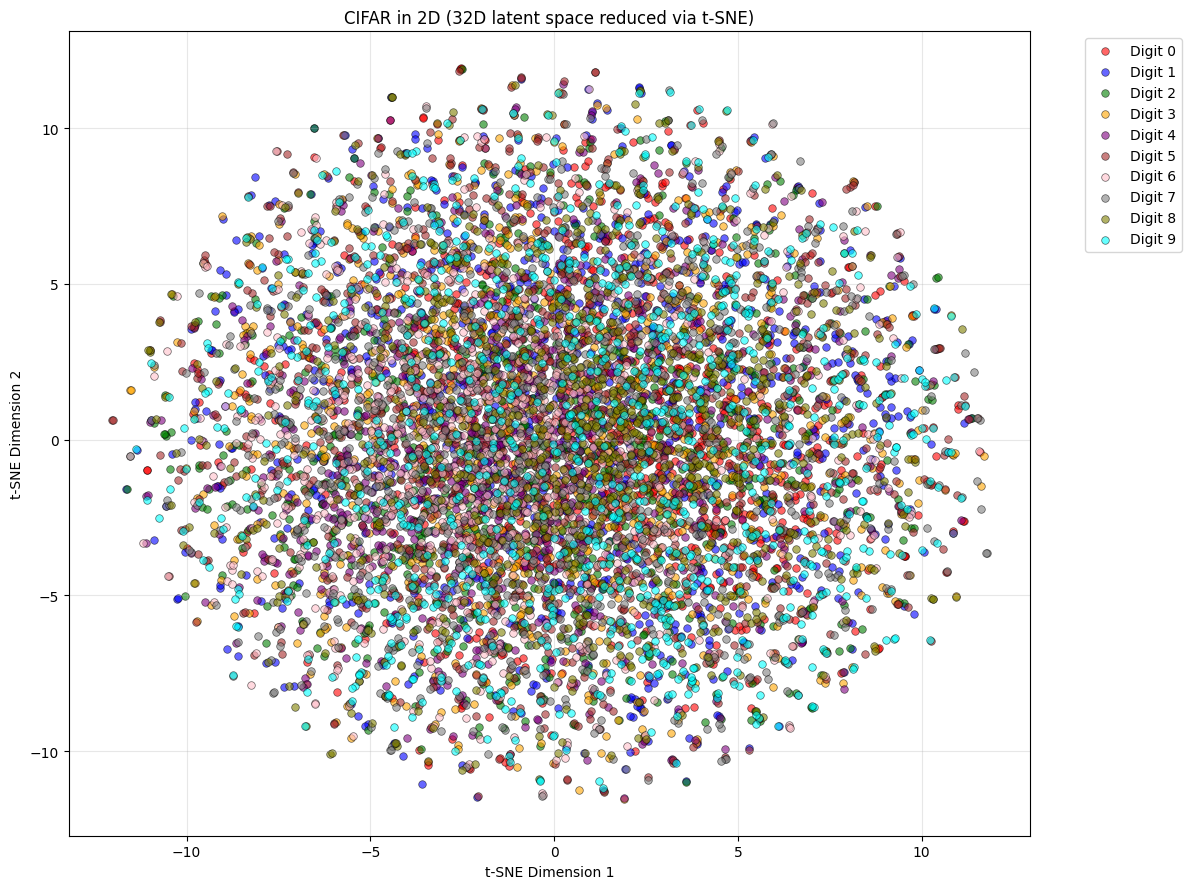


t-SNE visualization complete!
Original latent shape: (10000, 128)
t-SNE reduced shape: (10000, 2)


In [ ]:
# visualizing sampled latent vectors from approximate posterior (probabilistic encoder)

print("\nExtracting 32D latents...")
all_latents = []
all_labels = []

model4.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        img_flatten = images.flatten(1)
        mu_encoder, var_encoder = model4.encoder(img_flatten)
        latents_z = reparameterize(mu_encoder, var_encoder, n_samples=1).squeeze(1) # since only 1 latent vector is sampled, squeezing the dim-1

        all_latents.append(latents_z.cpu().numpy())
        all_labels.append(labels.numpy())

latents_32d = np.vstack(all_latents)
labels = np.concatenate(all_labels)

# Apply t-SNE to reduce 32D to 2D
print("\nApplying t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=1)
latents_2d = tsne.fit_transform(latents_32d)

# Plot
plt.figure(figsize=(12, 9))

# Define colors for each digit (0-9)
colors = ['red', 'blue', 'green', 'orange', 'purple',
          'brown', 'pink', 'gray', 'olive', 'cyan']

# Plot each digit with its own color
for digit in range(10):
    mask = labels == digit
    plt.scatter(latents_2d[mask, 0], latents_2d[mask, 1],
                c=colors[digit], label=f'Digit {digit}',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('CIFAR in 2D (32D latent space reduced via t-SNE)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nt-SNE visualization complete!")
print(f"Original latent shape: {latents_32d.shape}")
print(f"t-SNE reduced shape: {latents_2d.shape}")

In [ ]:
for i in range(latents_32d.shape[-1]):
  print(f"Dimension-{i}\t\tMean:{latents_32d[:,i].mean():.3f}\t\tVariance:{latents_32d[:,i].std()**2:.3f}")

Dimension-0		Mean:0.020		Variance:0.972
Dimension-1		Mean:0.053		Variance:0.997
Dimension-2		Mean:-0.035		Variance:0.969
Dimension-3		Mean:-0.028		Variance:0.994
Dimension-4		Mean:0.041		Variance:0.978
Dimension-5		Mean:0.011		Variance:1.013
Dimension-6		Mean:0.024		Variance:0.961
Dimension-7		Mean:-0.018		Variance:1.030
Dimension-8		Mean:-0.033		Variance:0.991
Dimension-9		Mean:0.027		Variance:1.019
Dimension-10		Mean:0.002		Variance:1.025
Dimension-11		Mean:-0.003		Variance:1.015
Dimension-12		Mean:0.044		Variance:1.022
Dimension-13		Mean:-0.002		Variance:0.963
Dimension-14		Mean:0.006		Variance:1.006
Dimension-15		Mean:-0.015		Variance:1.007
Dimension-16		Mean:0.045		Variance:0.985
Dimension-17		Mean:-0.015		Variance:0.971
Dimension-18		Mean:-0.005		Variance:1.043
Dimension-19		Mean:0.009		Variance:1.010
Dimension-20		Mean:-0.006		Variance:0.993
Dimension-21		Mean:0.037		Variance:1.012
Dimension-22		Mean:-0.020		Variance:1.024
Dimension-23		Mean:-0.018		Variance:1.000
Dimension-24		

In [ ]:
# interpolating the latents of same digit images and decoding

# first mapping and categorising the latent vector to respective digits
def group_latents_by_label(all_latents, all_labels):
    # Concatenate batches
    latents = np.concatenate(all_latents, axis=0)
    labels = np.concatenate(all_labels, axis=0)

    # Create dict: digit -> list of latents
    latent_dict = {i: [] for i in range(10)}

    for z, y in zip(latents, labels):
        latent_dict[int(y)].append(z)

    # Convert lists to arrays
    for k in latent_dict:
        latent_dict[k] = np.array(latent_dict[k])

    return latent_dict

# interpolation and decoding method
def interpolate_and_decode4(model, z1, z2, steps, device):
    """
    z1, z2: tensors of shape (latent_dim,)
    steps: number of interpolation points
    """

    model.eval()

    # Create interpolation coefficients
    alphas = torch.linspace(0, 1, steps, device=device)

    # Store outputs
    samples = []

    with torch.no_grad():
        for alpha in alphas:
            # Linear interpolation in latent space
            z = (1 - alpha) * z1 + alpha * z2
            z = z.unsqueeze(0).unsqueeze(1)  # shape (1, 1, latent_dim)

            # Decode
            x_sample = model.decoder(z)

            samples.append(x_sample.cpu())

    return torch.cat(samples, dim=0)

# fn for sampling, interpolating, decoding and plotting orchestration
def generate_interpolation_grid4(
    model,
    latent_dict,
    device,
    steps=4,
    img_shape=(28, 28)
):
    model.eval()

    all_rows = []

    for digit in range(10):
        latents = latent_dict[digit]

        # Randomly pick 2 latent vectors
        np.random.seed(101)
        idx = np.random.choice(len(latents), size=2, replace=False)
        z1 = torch.tensor(latents[idx[0]], device=device).float()
        z2 = torch.tensor(latents[idx[1]], device=device).float()

        # 🔹 Use your function here
        samples = interpolate_and_decode4(model, z1, z2, steps, device)
        samples = samples.cpu()  # (steps, input_dim)

        # Reshape each sample into image
        row_images = [
            samples[i].reshape(img_shape).permute(1,2,0).numpy()
            for i in range(steps)
        ]

        all_rows.append(row_images)

    # 🔹 Plot grid
    fig, axes = plt.subplots(10, steps, figsize=(steps * 2, 20))

    for i in range(10):
        for j in range(steps):
            axes[i, j].imshow(all_rows[i][j], cmap='gray')
            axes[i, j].axis('off')

            if j == 0:
                axes[i, j].set_ylabel(str(i), fontsize=12)

    plt.tight_layout()
    plt.show()

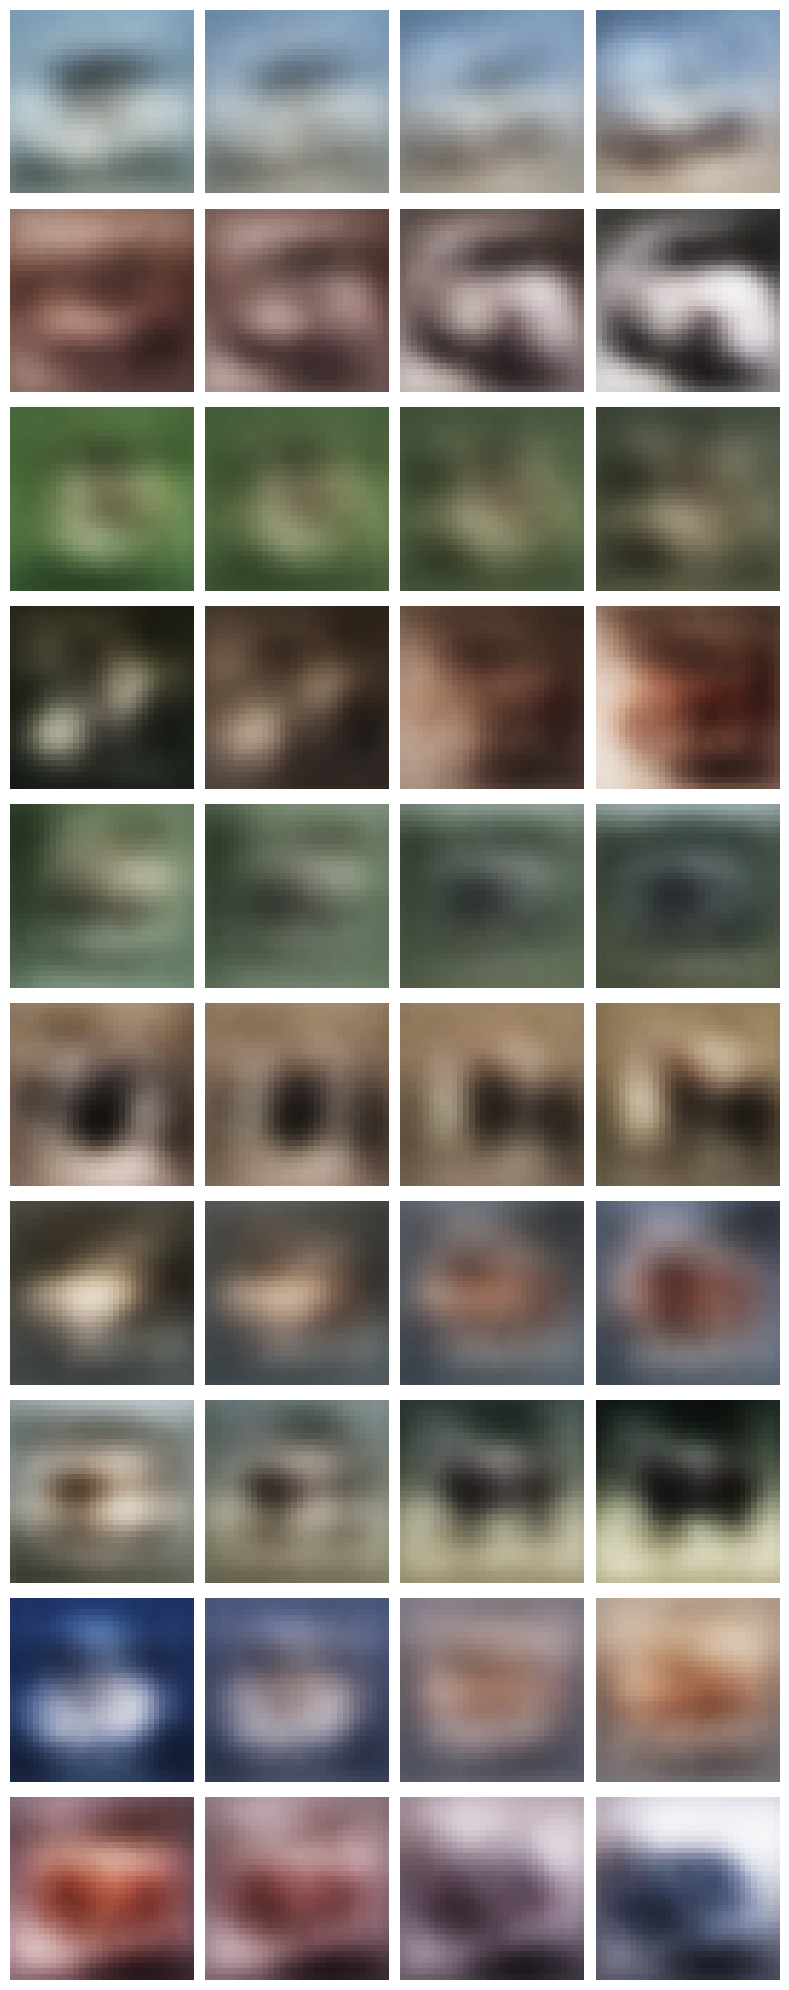

In [ ]:
latent_dict = group_latents_by_label(all_latents, all_labels)

generate_interpolation_grid4(model4, latent_dict, device, img_shape=(3, 32, 32))

From automobile to horse


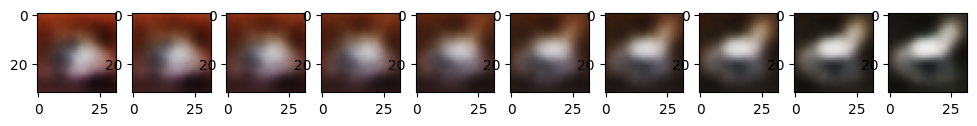

In [ ]:
z1 = torch.tensor(latent_dict[1][0], device=device)
z2 = torch.tensor(latent_dict[7][0], device=device)

print(f"From {idx_to_class[1]} to {idx_to_class[7]}")

interpolated_and_decoded4 = interpolate_and_decode4(model4, z1, z2, steps=10, device=device)

fig, axes = plt.subplots(1, 10, figsize=(12, 20))

for i in range(10):
  axes[i].imshow(interpolated_and_decoded4[i].reshape(3, 32, 32).permute(1,2,0).cpu().numpy(), cmap="gray")

plt.show()

Latent: tensor([-0.3561, -0.4527,  1.1028, -0.3743,  1.0345,  1.6702, -0.4052,  0.9799,
        -0.7668,  0.0201,  1.1038, -1.4496,  1.3548, -0.6148, -1.2499,  0.7438,
         0.8609, -1.1534, -1.6659,  1.5254,  0.4438, -0.3660, -0.8466, -0.6544,
         1.2063, -2.2716,  0.0414, -0.8544, -1.5801, -0.9456, -0.6814, -1.4662,
         0.4434, -1.3742,  1.9732,  0.3540,  0.4847, -1.0861, -0.3082,  0.5489,
         0.4614,  0.1554,  0.7893,  0.4507, -1.8227,  0.8071, -0.7816, -0.9430,
         1.5822, -0.8354, -1.3038, -1.6152,  1.0549,  1.6619, -2.8323,  0.5502,
        -0.7812,  1.2617, -0.6704,  0.8199, -1.5314, -0.4009,  0.1101, -0.0299,
         1.0488, -0.6288, -0.6111, -0.1427, -1.3776,  0.0207, -0.7827,  2.2601,
         0.1643, -1.1584, -0.1767, -1.3540, -0.4336, -1.2824, -0.2651,  0.2167,
         1.4414,  1.2646, -0.4266,  0.2555, -0.1047,  0.1150,  0.3903,  0.0487,
        -0.9894, -0.3630,  3.0981,  0.1569,  1.0711, -0.3600, -1.4018, -1.6173,
        -0.1489,  0.8647,  0.192

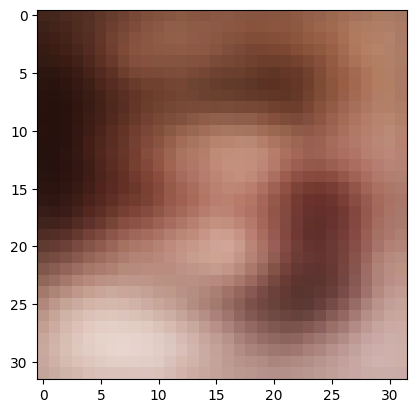

In [ ]:
# randomly sampling latent from prior (standard normal distribution) and decoding
latent_dim = 32
standard_normal_mean = torch.zeros(128, device=device)
standard_normal_std = torch.ones(128, device=device)
eps1 = torch.randn_like(standard_normal_mean, device=device)

sampled_latent_z = standard_normal_mean + standard_normal_std * eps1

print(f"Latent: {sampled_latent_z}")

model4.eval()
with torch.no_grad():
  reconstructed_sample = model4.decoder(eps1.unsqueeze(0).unsqueeze(1))
  reconstructed_sample = reconstructed_sample.reshape(3, 32, 32).permute(1,2,0).cpu().numpy()  # doing reshape(32,32,3) is wrong here

plt.imshow(reconstructed_sample, cmap="gray")
plt.show()

# **CIFAR - Convolutional Bernoulli VAE**

In [ ]:
# Convolutional Bernoulli VAE implementation
# Key difference from MLP version: uses conv/deconv layers
# but still produces a SINGLE latent vector (not spatial latent maps)

class ResidualBlock5(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 1),
        )

    def forward(self, x):
        return x + self.block(x)


class Encoder5(nn.Module):
    def __init__(self, in_channels, hidden, latent_dim):
        super().__init__()
        # Convolutional feature extractor
        self.conv_net = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 4, stride=2, padding=1),   # 32 -> 16
            nn.Conv2d(hidden, hidden, 4, stride=2, padding=1),        # 16 -> 8
            ResidualBlock5(hidden),
            ResidualBlock5(hidden),
        )
        # Flatten spatial dims and project to single latent vector
        self.flatten_dim = hidden * 8 * 8
        self.mean_ = nn.Linear(self.flatten_dim, latent_dim, bias=True)
        self.log_var = nn.Linear(self.flatten_dim, latent_dim, bias=True)

    def forward(self, x):
        # x: (B, C, H, W) - raw image, NOT flattened
        h = self.conv_net(x)           # (B, hidden, 8, 8)
        h = h.reshape(h.shape[0], -1)  # (B, hidden*8*8)
        mu = self.mean_(h)
        log_var = self.log_var(h)
        var = torch.exp(log_var)
        return mu, var


def reparameterize(mu, var, n_samples):
    # mu, var: (B, D)
    B, D = mu.shape
    eps = torch.randn(B, n_samples, D, device=mu.device)
    std = torch.sqrt(var).unsqueeze(1)  # (B, 1, D)
    z = mu.unsqueeze(1) + eps * std     # (B, n_samples, D)
    return z


class Decoder5(nn.Module):
    def __init__(self, out_channels, hidden, latent_dim):
        super().__init__()
        self.hidden = hidden
        # Project from latent to spatial feature map
        self.project = nn.Linear(latent_dim, hidden * 8 * 8, bias=True)
        # Deconvolutional reconstruction
        self.deconv_net = nn.Sequential(
            ResidualBlock5(hidden),
            ResidualBlock5(hidden),
            nn.ConvTranspose2d(hidden, hidden, 4, stride=2, padding=1),   # 8 -> 16
            nn.ConvTranspose2d(hidden, out_channels, 4, stride=2, padding=1),  # 16 -> 32
            nn.Sigmoid(),
        )

    def forward(self, latent_z):
        # latent_z: (B, n_samples, D)
        B, n_samples, D = latent_z.shape
        z = latent_z.reshape(B * n_samples, D)
        h = self.project(z)                                  # (B*n_samples, hidden*8*8)
        h = h.reshape(B * n_samples, self.hidden, 8, 8)     # (B*n_samples, hidden, 8, 8)
        reconst_img = self.deconv_net(h)                     # (B*n_samples, out_channels, 32, 32)
        reconst = reconst_img.reshape(B, n_samples, -1)     # (B, n_samples, out_channels*32*32)
        return reconst


class VAE5(nn.Module):
    def __init__(self, in_channels, out_channels, hidden, latent_dim):
        super().__init__()
        self.encoder = Encoder5(in_channels, hidden, latent_dim)
        self.decoder = Decoder5(out_channels, hidden, latent_dim)

    def forward(self, x, n_samples=1):
        # x: (B, C, H, W) - raw image input
        mu_encoder, var_encoder = self.encoder(x)
        latent_z = reparameterize(mu_encoder, var_encoder, n_samples)
        reconst = self.decoder(latent_z)
        return mu_encoder, var_encoder, reconst

In [ ]:
def calc_batch_loss5(model, x, device, n_samples=5):
    x = x.to(device)
    # NOTE: x is NOT flattened - conv encoder takes raw (B, C, H, W)
    mu_encoder, var_encoder, reconst = model(x, n_samples)
    dkl = torch.sum(1 + torch.log(var_encoder) - torch.square(mu_encoder) - var_encoder, dim=-1).mean() * (-1/2)
    # Flatten x for BCE computation (reconst is already flat: B, n_samples, C*H*W)
    x_flat = x.flatten(1)
    x_exp = x_flat.unsqueeze(1)
    bce = nn.functional.binary_cross_entropy(
        reconst,
        x_exp.expand_as(reconst),
        reduction='none'
    )
    bce = bce.sum(dim=-1)
    bce = bce.mean(dim=1)
    reconst_loss = bce.mean()
    loss = reconst_loss + dkl
    return loss, reconst_loss, dkl

In [ ]:
def evaluate5(loader, model, device, max_batch=5, n_samples=5):
    total_loss = 0
    total_reconst_loss, total_dkl = 0, 0

    if max_batch <= 0:
        return float("nan")
    elif max_batch is None:
        max_batch = len(loader)
    else:
        max_batch = min(max_batch, len(loader))

    for i, (x, _) in enumerate(loader):
        if i < max_batch:
            with torch.no_grad():
                # NOTE: No x.flatten(1) - conv encoder handles raw images
                loss, reconst_loss, dkl = calc_batch_loss5(model, x, device, n_samples)
            total_loss += loss.item()
            total_reconst_loss += reconst_loss.item()
            total_dkl += dkl.item()
        else:
            break

    return total_loss/max_batch, total_reconst_loss/max_batch, total_dkl/max_batch

In [ ]:
def sample_from_decoder5(model, x, device, n_samples=1):
    x = x.to(device)
    with torch.no_grad():
        # NOTE: x is NOT flattened - conv encoder takes raw images
        mu_encoder, var_encoder, reconst = model(x, n_samples=n_samples)
    return reconst

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:
cifar_train = CIFAR10(
    root="/content/drive/My Drive/GenAI/Data",
    train=True,
    download=True,
    transform=transform
    )

cifar_test = CIFAR10(
    root="/content/drive/My Drive/GenAI/Data",
    train=False,
    download=True,
    transform=transform
    )

In [ ]:
print(f"Train size: {len(cifar_train)}")
print(f"Test size: {len(cifar_test)}")
print(f"Image shape: {cifar_train[0][0].shape}")

Train size: 50000
Test size: 10000
Image shape: torch.Size([3, 32, 32])


In [ ]:
cifar_train[0][0].max(), cifar_train[0][0].min(), cifar_train[0][0].unique().numel()

(tensor(1.), tensor(0.), 248)

In [ ]:
cifar_train.class_to_idx

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

In [ ]:
idx_to_class = {v:k for k,v in cifar_train.class_to_idx.items()}

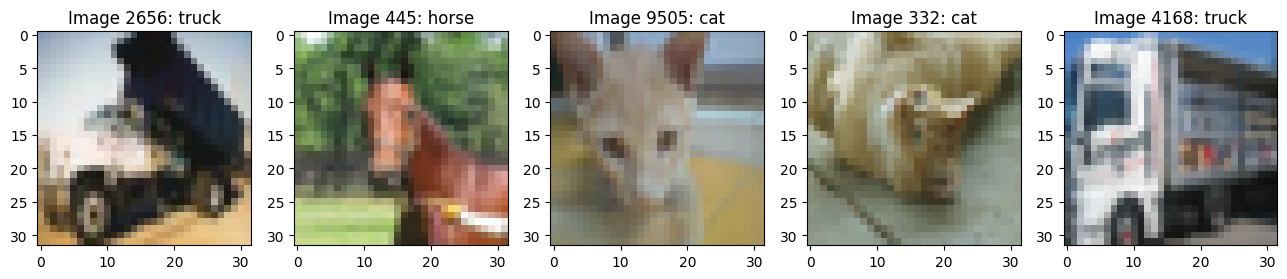

In [ ]:
np.random.seed(123)

random_indices = np.random.choice(len(cifar_test), size=5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(16, 8))

for ax,i in zip(axes, random_indices):
  ax.imshow(torch.permute(cifar_test[i][0], (1,2,0)), cmap="gray")
  ax.set_title(f"Image {i}: {idx_to_class[cifar_test[i][1]]}")

plt.show()

In [ ]:
samples = torch.stack([cifar_test[i][0] for i in random_indices], dim=0)
labels = torch.stack([torch.tensor(cifar_test[i][1]) for i in random_indices], dim=0)

In [ ]:
train_loader = DataLoader(cifar_train, batch_size=64, shuffle=True, num_workers=0)
test_loader = DataLoader(cifar_test, batch_size=64, shuffle=False, num_workers=0)

In [ ]:
torch.manual_seed(123)
# Conv VAE: in_channels=3, out_channels=3, hidden=128, latent_dim=32
model5 = VAE5(3, 3, 256, 128)
model5.to(device)

optimizer5 = torch.optim.Adam(model5.parameters(), lr=0.0001)
epochs = 30

global_step5 = 0
train_losses5, val_losses5 = [], []
train_reconst_losses5, val_reconst_losses5 = [], []
train_dkl_losses5, val_dkl_losses5 = [], []

t9 = time.time()

model5.train()
for epoch in range(epochs):
    for x, _ in train_loader:
        optimizer5.zero_grad()
        # NOTE: No x.flatten(1) - conv encoder takes raw (B, C, H, W) images
        loss, _, _ = calc_batch_loss5(model5, x, device, n_samples=5)
        loss.backward()
        optimizer5.step()
        global_step5 += 1

        if global_step5 % 500 == 0:
            model5.eval()
            train_loss5, train_reconst_loss5, train_dkl5 = evaluate5(train_loader, model5, device, max_batch=20, n_samples=5)
            val_loss5, val_reconst_loss5, val_dkl5 = evaluate5(test_loader, model5, device, max_batch=20, n_samples=5)
            model5.train()
            print(f"Epoch: {epoch:3d} \t\t Step: {global_step5:5d}")
            print(f"\t\t\tTrain Loss: {train_loss5}")
            print(f"\t\t\tValidation Loss: {val_loss5}")
            train_losses5.append(train_loss5)
            val_losses5.append(val_loss5)
            train_reconst_losses5.append(train_reconst_loss5)
            val_reconst_losses5.append(val_reconst_loss5)
            train_dkl_losses5.append(train_dkl5)
            val_dkl_losses5.append(val_dkl5)
            if global_step5 % 1000 == 0:
                model5.eval()
                # NOTE: samples are NOT flattened for conv encoder
                reconstructed = sample_from_decoder5(model5, samples, device, n_samples=1).reshape(5, 3, 32, 32).cpu()
                fig, axes = plt.subplots(1, 5, figsize=(16, 8))
                for ax,i in zip(axes, range(5)):
                    ax.imshow(torch.permute(reconstructed[i], (1,2,0)))
                    ax.set_title(f"Image {i}: {idx_to_class[labels[i].item()]}")
                plt.show()
                model5.train()

t10 = time.time()

print(f"Total training time: {t10-t9}s")

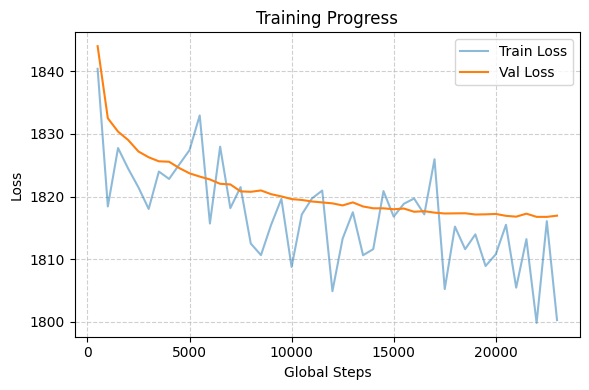

In [ ]:
plot_training_results(train_losses5, val_losses5, 500, title="Training Progress")

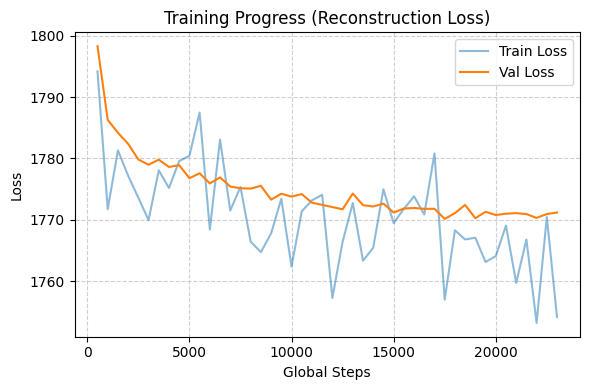

In [ ]:
plot_training_results(train_reconst_losses5, val_reconst_losses5, 500, title="Training Progress (Reconstruction Loss)")

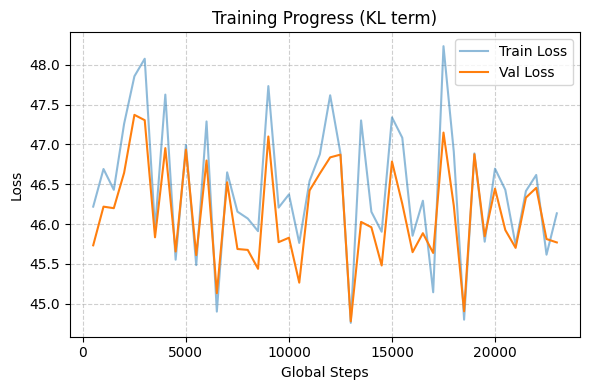

In [ ]:
plot_training_results(train_dkl_losses5, val_dkl_losses5, 500, title="Training Progress (KL term)")


Extracting 32D latents...

Applying t-SNE (this may take a minute)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 10000 samples in 1.284s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 2.510185
[t-SNE] KL divergence after 250 iterations with early exaggeration: 96.682976
[t-SNE] KL divergence after 1000 iterations: 4.903953


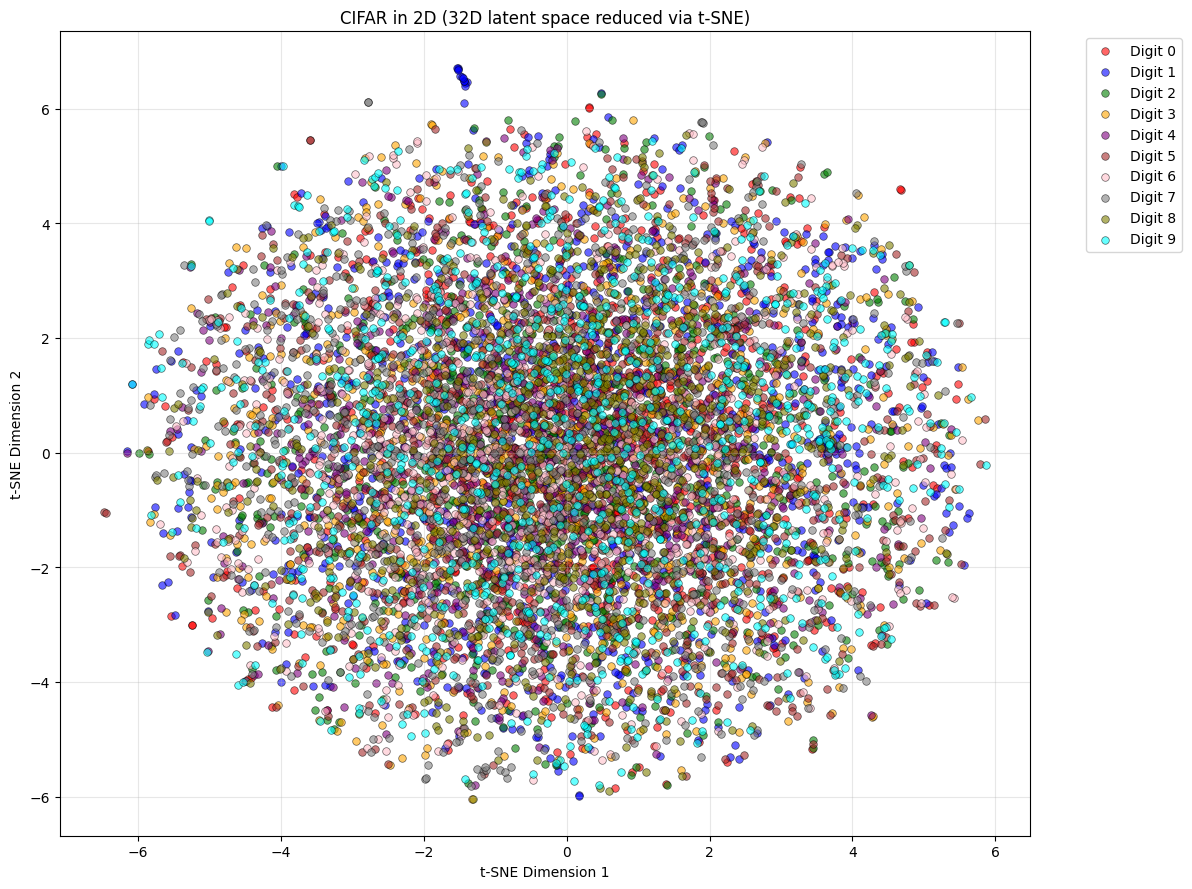


t-SNE visualization complete!
Original latent shape: (10000, 128)
t-SNE reduced shape: (10000, 2)


In [ ]:
# visualizing sampled latent vectors from approximate posterior (probabilistic encoder)

print("\nExtracting 32D latents...")
all_latents = []
all_labels = []

model5.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        mu_encoder, var_encoder = model5.encoder(images)
        latents_z = reparameterize(mu_encoder, var_encoder, n_samples=1).squeeze(1) # since only 1 latent vector is sampled, squeezing the dim-1

        all_latents.append(latents_z.cpu().numpy())
        all_labels.append(labels.numpy())

latents_32d = np.vstack(all_latents)
labels = np.concatenate(all_labels)

# Apply t-SNE to reduce 32D to 2D
print("\nApplying t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=1)
latents_2d = tsne.fit_transform(latents_32d)

# Plot
plt.figure(figsize=(12, 9))

# Define colors for each digit (0-9)
colors = ['red', 'blue', 'green', 'orange', 'purple',
          'brown', 'pink', 'gray', 'olive', 'cyan']

# Plot each digit with its own color
for digit in range(10):
    mask = labels == digit
    plt.scatter(latents_2d[mask, 0], latents_2d[mask, 1],
                c=colors[digit], label=f'Digit {digit}',
                alpha=0.6, s=30, edgecolors='black', linewidth=0.5)

plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('CIFAR in 2D (32D latent space reduced via t-SNE)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nt-SNE visualization complete!")
print(f"Original latent shape: {latents_32d.shape}")
print(f"t-SNE reduced shape: {latents_2d.shape}")

In [ ]:
for i in range(latents_32d.shape[-1]):
  print(f"Dimension-{i}\t\tMean:{latents_32d[:,i].mean():.3f}\t\tVariance:{latents_32d[:,i].std()**2:.3f}")

Dimension-0		Mean:-0.035		Variance:1.041
Dimension-1		Mean:0.003		Variance:0.975
Dimension-2		Mean:-0.014		Variance:0.981
Dimension-3		Mean:0.006		Variance:0.984
Dimension-4		Mean:-0.006		Variance:1.012
Dimension-5		Mean:-0.016		Variance:1.000
Dimension-6		Mean:0.015		Variance:0.994
Dimension-7		Mean:-0.001		Variance:1.042
Dimension-8		Mean:-0.012		Variance:0.992
Dimension-9		Mean:0.020		Variance:0.983
Dimension-10		Mean:-0.011		Variance:0.997
Dimension-11		Mean:-0.009		Variance:0.935
Dimension-12		Mean:-0.007		Variance:1.031
Dimension-13		Mean:-0.005		Variance:0.983
Dimension-14		Mean:0.041		Variance:0.963
Dimension-15		Mean:0.019		Variance:0.974
Dimension-16		Mean:-0.005		Variance:0.997
Dimension-17		Mean:-0.019		Variance:1.027
Dimension-18		Mean:-0.009		Variance:0.988
Dimension-19		Mean:-0.020		Variance:1.024
Dimension-20		Mean:-0.012		Variance:0.965
Dimension-21		Mean:-0.014		Variance:1.037
Dimension-22		Mean:0.008		Variance:1.006
Dimension-23		Mean:0.011		Variance:1.054
Dimension-

In [ ]:
# interpolating the latents of same digit images and decoding

# first mapping and categorising the latent vector to respective digits
def group_latents_by_label(all_latents, all_labels):
    # Concatenate batches
    latents = np.concatenate(all_latents, axis=0)
    labels = np.concatenate(all_labels, axis=0)

    # Create dict: digit -> list of latents
    latent_dict = {i: [] for i in range(10)}

    for z, y in zip(latents, labels):
        latent_dict[int(y)].append(z)

    # Convert lists to arrays
    for k in latent_dict:
        latent_dict[k] = np.array(latent_dict[k])

    return latent_dict

# interpolation and decoding method
def interpolate_and_decode5(model, z1, z2, steps, device):
    """
    z1, z2: tensors of shape (latent_dim,)
    steps: number of interpolation points
    """

    model.eval()

    # Create interpolation coefficients
    alphas = torch.linspace(0, 1, steps, device=device)

    # Store outputs
    samples = []

    with torch.no_grad():
        for alpha in alphas:
            # Linear interpolation in latent space
            z = (1 - alpha) * z1 + alpha * z2
            z = z.unsqueeze(0).unsqueeze(1)  # shape (1, 1, latent_dim)

            # Decode
            x_sample = model.decoder(z)

            samples.append(x_sample.cpu())

    return torch.cat(samples, dim=0)

# fn for sampling, interpolating, decoding and plotting orchestration
def generate_interpolation_grid5(
    model,
    latent_dict,
    device,
    steps=4,
    img_shape=(28, 28)
):
    model.eval()

    all_rows = []

    for digit in range(10):
        latents = latent_dict[digit]

        # Randomly pick 2 latent vectors
        np.random.seed(101)
        idx = np.random.choice(len(latents), size=2, replace=False)
        z1 = torch.tensor(latents[idx[0]], device=device).float()
        z2 = torch.tensor(latents[idx[1]], device=device).float()

        # 🔹 Use your function here
        samples = interpolate_and_decode5(model, z1, z2, steps, device)
        samples = samples.cpu()  # (steps, input_dim)

        # Reshape each sample into image
        row_images = [
            samples[i].reshape(img_shape).permute(1,2,0).numpy()
            for i in range(steps)
        ]

        all_rows.append(row_images)

    # 🔹 Plot grid
    fig, axes = plt.subplots(10, steps, figsize=(steps * 2, 20))

    for i in range(10):
        for j in range(steps):
            axes[i, j].imshow(all_rows[i][j], cmap='gray')
            axes[i, j].axis('off')

            if j == 0:
                axes[i, j].set_ylabel(str(i), fontsize=12)

    plt.tight_layout()
    plt.show()

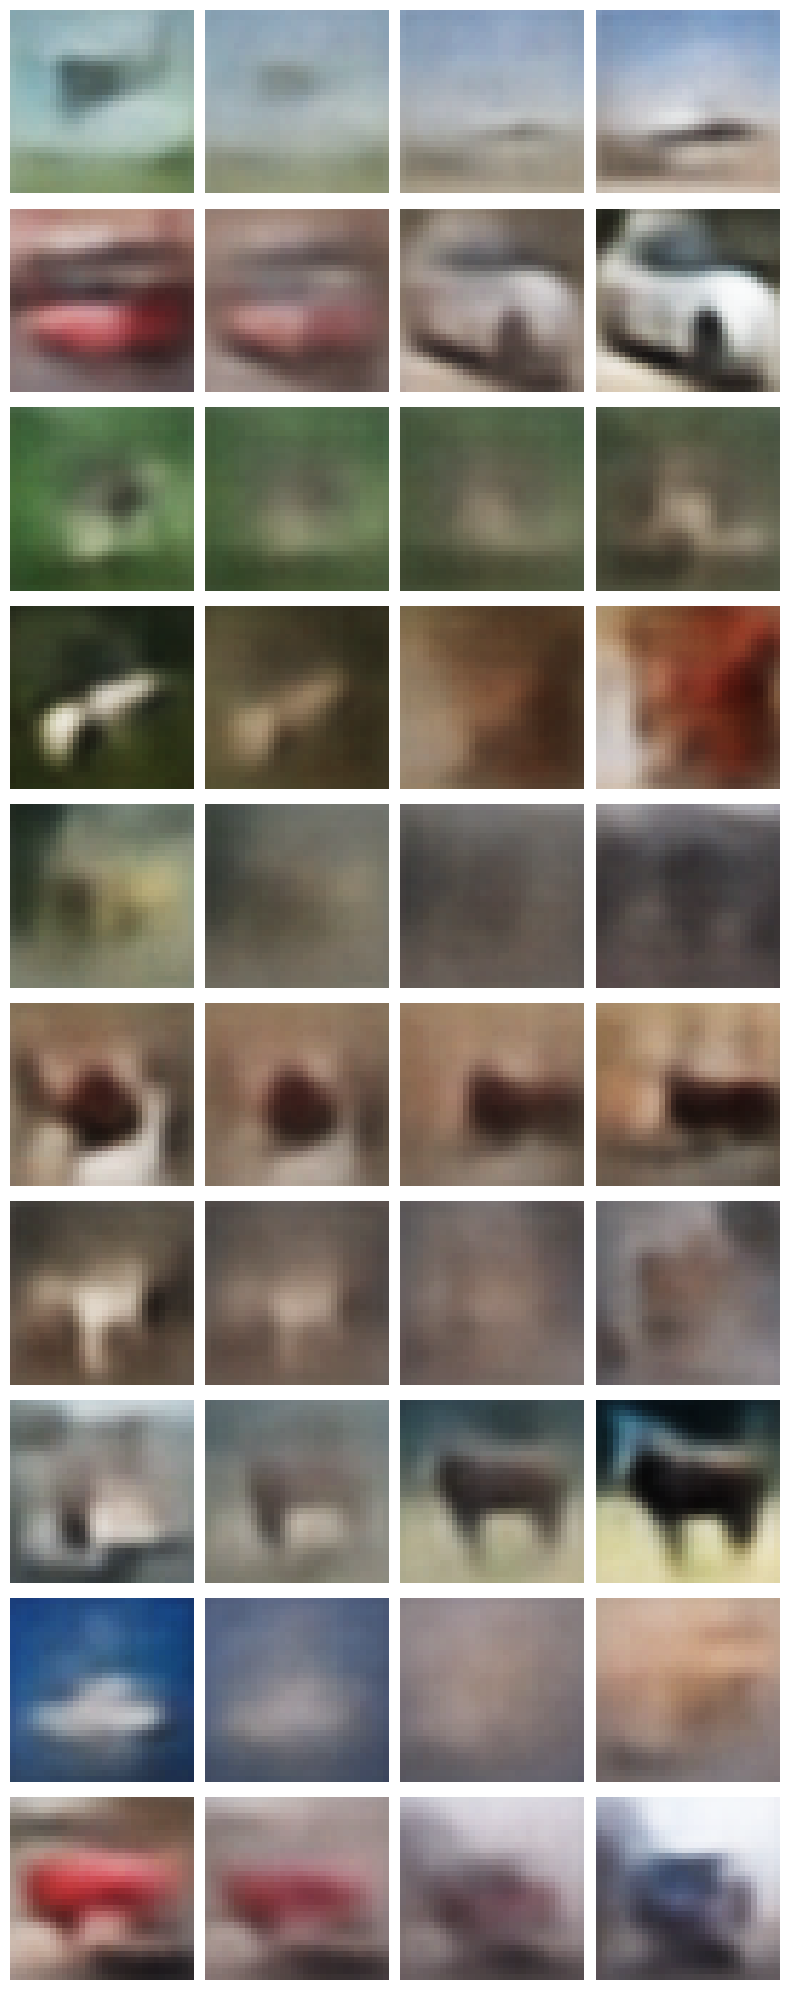

In [ ]:
latent_dict = group_latents_by_label(all_latents, all_labels)

generate_interpolation_grid5(model5, latent_dict, device, img_shape=(3, 32, 32))

From automobile to horse


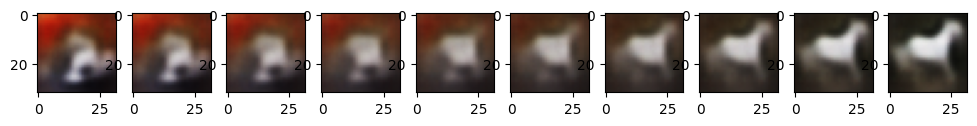

In [ ]:
z1 = torch.tensor(latent_dict[1][0], device=device)
z2 = torch.tensor(latent_dict[7][0], device=device)

print(f"From {idx_to_class[1]} to {idx_to_class[7]}")

interpolated_and_decoded5 = interpolate_and_decode5(model5, z1, z2, steps=10, device=device)

fig, axes = plt.subplots(1, 10, figsize=(12, 20))

for i in range(10):
  axes[i].imshow(interpolated_and_decoded5[i].reshape(3, 32, 32).permute(1,2,0).cpu().numpy(), cmap="gray")

plt.show()

Latent: tensor([-1.7013e-01, -5.4582e-01,  5.5348e-01,  7.4324e-01,  3.2096e-01,
         1.5896e+00,  5.2078e-01,  1.2907e+00, -2.1529e-01,  2.9308e-01,
        -3.1454e-01,  1.5145e-01, -1.3544e+00, -7.1489e-01, -1.0000e-01,
        -1.1051e+00, -7.2091e-01, -3.9766e-01, -4.8684e-01, -2.3212e+00,
         1.9577e-01,  9.4018e-02, -8.5797e-01,  7.8759e-01,  9.3716e-01,
         7.3994e-02, -1.0321e-01,  8.7893e-01,  1.4012e+00,  1.8210e+00,
        -4.2601e-01,  2.0814e-01,  3.4568e-01, -1.2287e+00, -2.2793e+00,
        -9.5724e-01, -8.1869e-01, -6.8020e-01,  1.9865e-01,  6.7382e-01,
         3.4865e-01, -4.9879e-01, -7.2627e-02, -5.2776e-01,  1.2053e+00,
        -4.3581e-01, -6.5495e-01,  1.1212e+00, -4.4061e-01, -1.0708e+00,
        -6.6556e-01,  5.2608e-01,  6.9322e-01,  1.0023e+00, -1.4296e+00,
         1.5236e-01,  1.6340e-01, -3.0193e+00, -5.4862e-01,  9.0803e-02,
         1.6593e+00, -8.1352e-01, -2.6287e-01,  1.2860e+00,  2.1611e+00,
        -2.5397e-01, -1.6621e+00, -1.1885e+

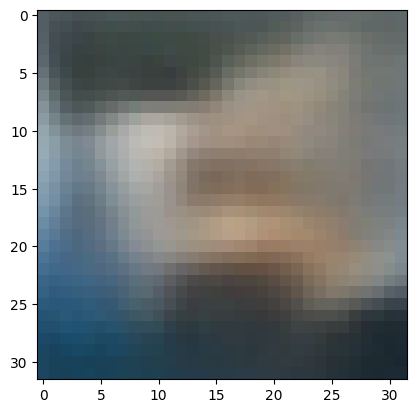

In [ ]:
# randomly sampling latent from prior (standard normal distribution) and decoding
latent_dim = 32
standard_normal_mean = torch.zeros(128, device=device)
standard_normal_std = torch.ones(128, device=device)
eps1 = torch.randn_like(standard_normal_mean, device=device)

sampled_latent_z = standard_normal_mean + standard_normal_std * eps1

print(f"Latent: {sampled_latent_z}")

model5.eval()
with torch.no_grad():
  reconstructed_sample = model5.decoder(eps1.unsqueeze(0).unsqueeze(1))
  reconstructed_sample = reconstructed_sample.reshape(3, 32, 32).permute(1,2,0).cpu().numpy()  # doing reshape(32,32,3) is wrong here

plt.imshow(reconstructed_sample, cmap="gray")
plt.show()